# Project Name : Cellphone Price Range
# Contribution : Individual
# By-Shweta Yaligar
# Id-PTID-CDS-AUG-25-3026

# Project Summary:

This is data science project aimed to predict mobile phone price ranges based on their specifications using machine learning algorithms.The dataset consisted of various features related to mobile phones such as battery capacity,RAM,internal memory,camera quality,and other hardware specifications.The dataset was split into traning and testing sets and several machine learning algorithms such as Logistic Regression,Decision Tree,Random Forest,and Support Vector Machines(SVM)were applied to the training set.The Reandom Forest algorithm was chosen as the final model due to its high accuracy and F1-score.The project concluded that predictive modeling can be an affective approach for mobile price range detection and highlighted the importance of data preprocessing and feature engeering for improving model accuracy.

Link: https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1009-CellphonePrice.zip

# Problem Statement:

Companies operating in the fiercely competitive mobile phone market aim to comprehend sales information regarding mobile phones and the underlying factors that affect their pricing.Their goal is tyo establish a correlation between the various features of a mobile phone, such as RAM, internal memory, etc., and its selling price. However,the focus is not on predicting the exact price of the device, but rather determining a price range that indicates its level of affordability..

**Data description-**

    

*   **Battery_power** - Total energy a battery can store in one time measured in mAh
*  **Blue** - Has bluetooth or not


*   **Clock_speed** - speed at which microprocessor executes instructions
*   **Dual_sim** - Has dual sim support or not


*   **Fc**- Front Camera mega pixels
*   **Four_g** - Has 4G or not


*   **Int_memory** - Internal Memory in Gigabytes

*   **M_dep** - Mobile Depth in cm

*   **Mobile_wt** - Weight of mobile phone

*   **N_cores** - Number of cores of processor

*   **Pc**- Primary Camera mega pixels
*   **Px_height** - Pixel Resolution Height


*   **Px_width** - Pixel Resolution Width


*  **Ram**- Random Access Memory in Megabytes


*   **Sc_h** - Screen Height of mobile in cm


*   **Sc_w** - Screen Width of mobile in cm


*   **Talk_time** - longest time that a single battery charge will last when you are

*  **Three_g**- Has 3G or not

*   **Touch_screen** - Has 3G or not
*   **Wifi** - Has wifi or not


*   **Price_range** - This is the target variable with value of 0(low cost), 1(medium cost), 2(high cost) and 3(very high cost).

# Importing Libraries and File Reading

In [ ]:
# importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# setting max display column limit to 30
pd.set_option("display.max_columns",30)

#set style
# plt.style.use('seaborn')
sns.set()

#set style
# plt.style.use('seaborn')
sns.set()

# setting font weight,label weight,title weight to bold and setting tittle size, label size,fontsize.
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 25
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['figure.titlesize'] = 15

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Mounting drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# CSV file location path
file_path ="/content/drive/MyDrive/Classification_Capstone/data_cellphone_price_precdtion.csv"

In [ ]:
# importing csv file into Pandas dataframe.
mobile_data=pd.read_csv(file_path)

In [ ]:
# first 5 rows
mobile_data.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,1


In [ ]:
# Last 5 Rows of the data

mobile_data.tail()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1995,794,1,0.5,1,0,1,2,0.8,106,6,14,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,3,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,3,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,5,336,670,869,18,10,19,1,1,1,0
1999,510,1,2.0,1,5,1,45,0.9,168,6,16,483,754,3919,19,4,2,1,1,1,3


In [ ]:
# lets Check the shape of data
print(mobile_data.shape)
print(f'Total Rows = {mobile_data.shape[0]}\nTotal Columns = {mobile_data.shape[1]}')


(2000, 21)
Total Rows = 2000
Total Columns = 21


In [ ]:
# Checking Statistics of the data
mobile_data.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


In [ ]:
# Checking How many observations having screen width value as 0.
print(mobile_data[mobile_data['sc_w']==0].shape[0])

180


In [ ]:
# Checking How many observations having px_height value as 0.
print(mobile_data[mobile_data['px_height']==0].shape[0])

2


In [ ]:
# As there are only 2 observations having px_height=0.  so we will drop it.
mobile_data=mobile_data[mobile_data['px_height']!=0]

# **Nearest Neighbors Imputations (KNNImputer)**

Missing values are imputed using the k-Nearest Neighbors approach where a Euclidean distance is used to find the nearest neighbors.

Let's take the above example of the dataset see how it works.

    

*   Before using KNN Imputer we need to repalce 0 with NAN values. so that it will work.

In [ ]:
# Replacing 0 with NAN so tha we can implement KNN Imputer.
mobile_data['sc_w']=mobile_data['sc_w'].replace(0,np.nan)

In [ ]:
# import KNN imputer from sklearn
from sklearn.impute import KNNImputer
impute_knn = KNNImputer(n_neighbors=1)
mobile_data=pd.DataFrame(impute_knn.fit_transform(mobile_data),columns=mobile_data.columns)

In [ ]:
# Checking shape
mobile_data.shape

(1998, 21)

In [ ]:
# Checking How many observations having sc_w value as 0.
mobile_data[mobile_data['sc_w']==0].shape[0]

0

# **Thus we have handled the mismatched values of the data.**

In [ ]:
# Checking the datatypes, non null values
mobile_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1998 entries, 0 to 1997
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  1998 non-null   float64
 1   blue           1998 non-null   float64
 2   clock_speed    1998 non-null   float64
 3   dual_sim       1998 non-null   float64
 4   fc             1998 non-null   float64
 5   four_g         1998 non-null   float64
 6   int_memory     1998 non-null   float64
 7   m_dep          1998 non-null   float64
 8   mobile_wt      1998 non-null   float64
 9   n_cores        1998 non-null   float64
 10  pc             1998 non-null   float64
 11  px_height      1998 non-null   float64
 12  px_width       1998 non-null   float64
 13  ram            1998 non-null   float64
 14  sc_h           1998 non-null   float64
 15  sc_w           1998 non-null   float64
 16  talk_time      1998 non-null   float64
 17  three_g        1998 non-null   float64
 18  touch_sc



*   We don't have any object data type in our data set.

*   Also we have Zero null values in data set.
*   Price_range is our target variable.






In [ ]:
# Checking Null values.
mobile_data.isna().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


Text(0.5, 1.0, 'Visualising Missing Vlaues')

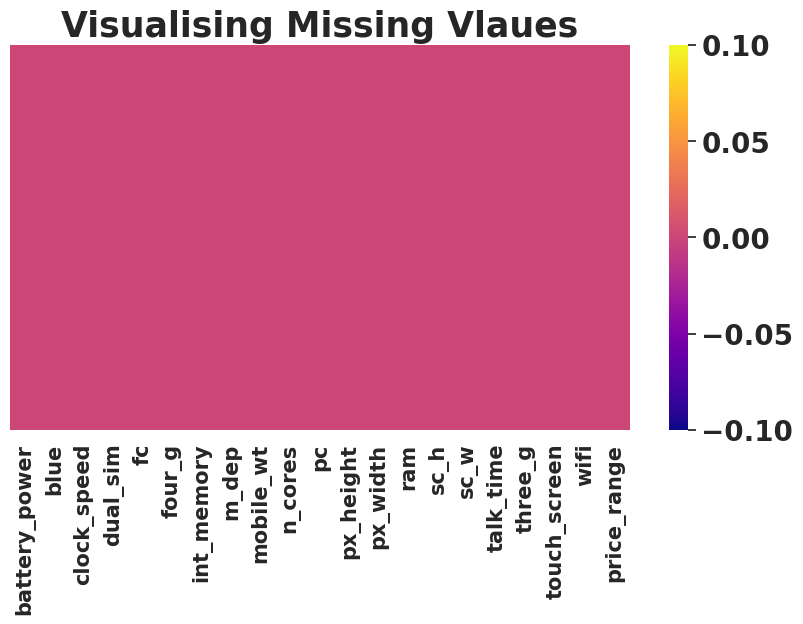

In [ ]:
# Visulazing null values using heatmap.
plt.figure(figsize=(10,5))
sns.heatmap(mobile_data.isnull(),cmap='plasma',annot=False,yticklabels=False)
plt.title("Visualising Missing Vlaues")

## No Null values found.Which is good thing for us.

# **EDA(Exploratory Data Analysis)**

In [ ]:
# Checking Duplicate values in data set.
print(f' We have {mobile_data.duplicated().sum()} duplicate values in our data set.')

 We have 0 duplicate values in our data set.


**# Let's have look at target variable first...!**

In [ ]:
# lets have look at our target variable's counts
price_range_values=mobile_data['price_range'].value_counts()
price_range_values

,count
price_range,
2.0,500
0.0,500
1.0,499
3.0,499


Wow..! we have almost equal number of observations for each category.Thus we don't have imbalanced target variable.Accuracy score will be the best evalaution metric for us to select the model.

This is the target variable with value of
   

*  0=low cost,

*   1=medium cost,
*   2=high cost,


*  3=very high cost.



<Axes: ylabel='count'>

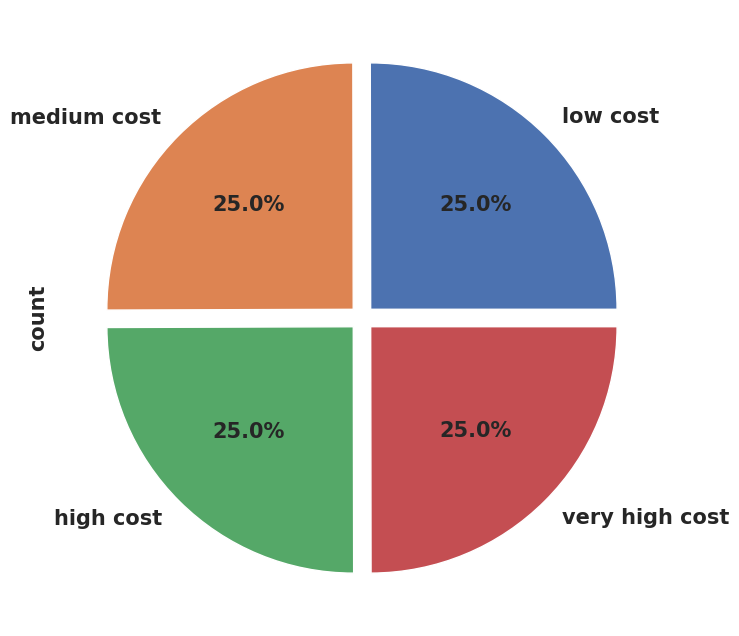

In [ ]:
# Visualizing the Target variable's class distribution.
labels=["low cost", "medium cost", "high cost", "very high cost"]
price_range_values.plot.pie(explode=[0.05]*4,labels=labels,autopct='%1.1f%%',figsize=(12,8),fontsize=15)  #plotting pie chart



*   We can see that our target variable is eually distributed.
*   Thus we don't have to worry about data imbalance and there is no need of oversampling or undersampling.Which is good for us.



# **Correlation of target variable i.e Dependent variable with the other independent variable.**

<Axes: >

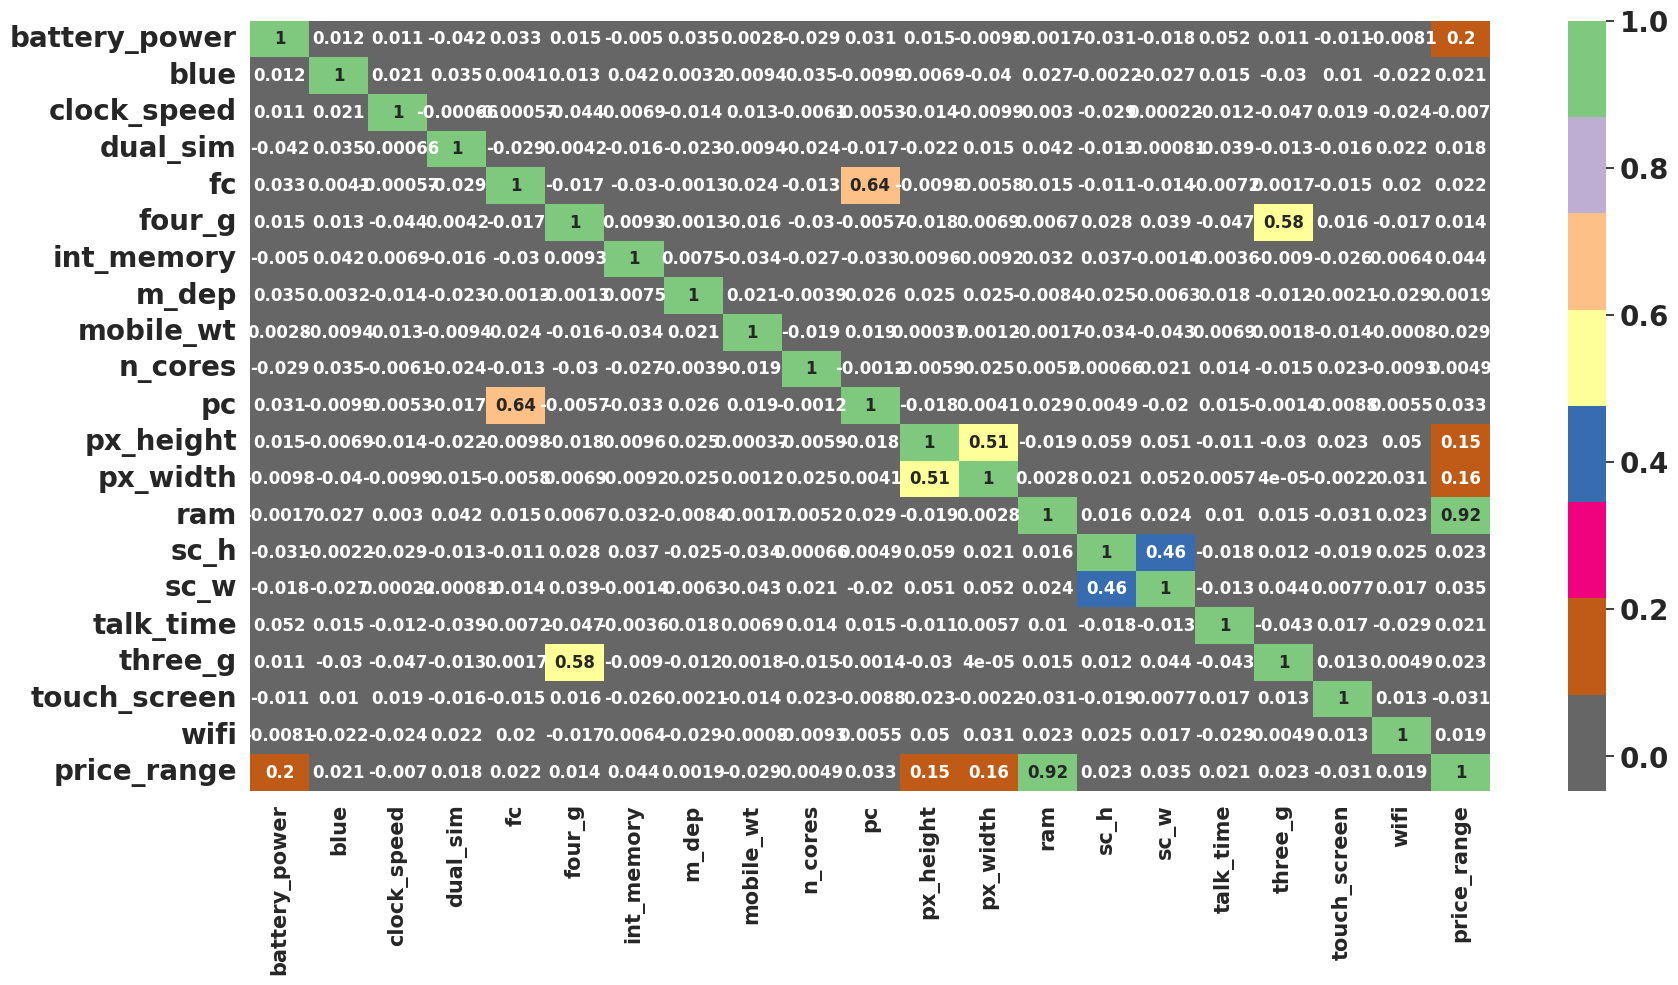

In [ ]:
corr= mobile_data.corr()
plt.figure(figsize=(20,10))
sns.heatmap(corr,annot=True,cmap=plt.cm.Accent_r)

# **Observations:**

    

*   RAM has strong positive correlation with the Price_range.and we know that mobiles with high RAM are very costly.Thus RAM increases price range also increase.

*  Battery_power also has positive correlation with the price range.Generally mobiles having high prices comes with good battery power.

*   Also px_height and px_width(Pixel Resolution Height and Width)are positively correlated.Generally High price range mobiles have good resolutions.
*   Four_g and Three_g are highly positively correlated.Nowdays most of the smart mobiles has both type of options.This could be the reason that they are correlated.

*  primary camera i.e pc and front camera fc are positively correlated.


*   sc_h abd sc_w are positively correlated.



In [ ]:
mobile_data.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

# **Univariate Analysis of Categorical columns.**

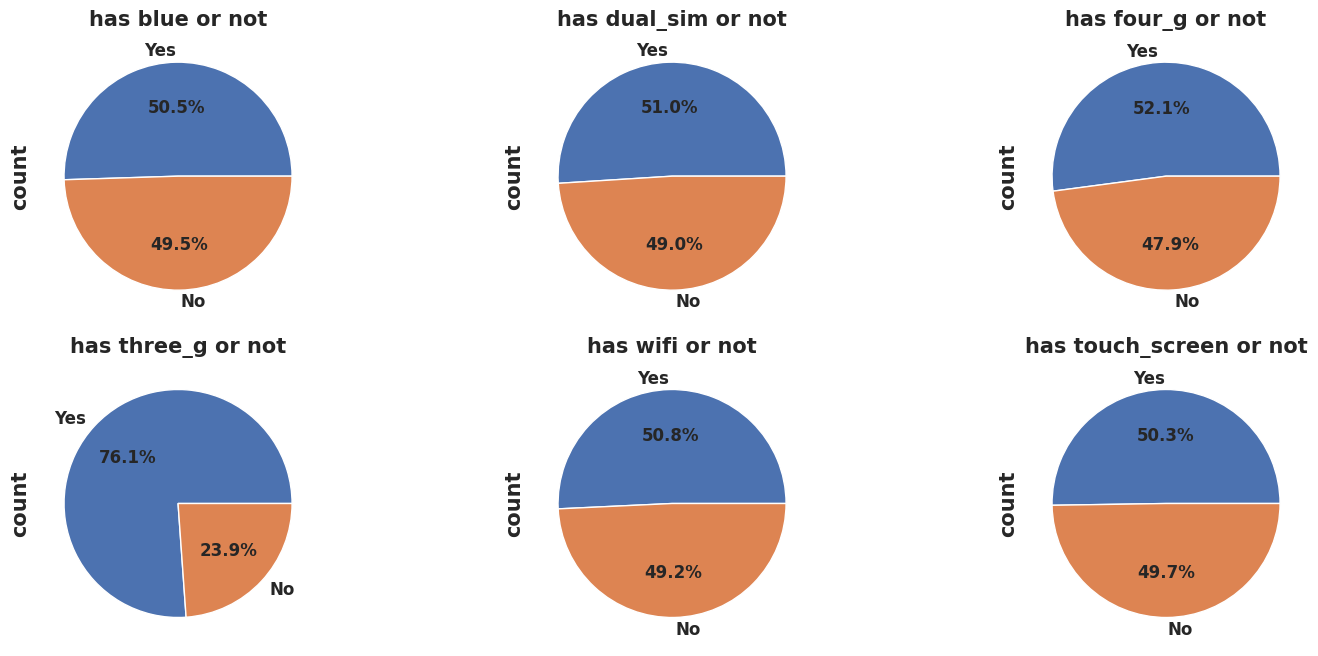

In [ ]:
# Plotting the piecharts for binary categorical variables.
plt.figure(figsize=(15,10))

rows=3
col=3
count=1
var_list=['blue','dual_sim','four_g','three_g','wifi','touch_screen']
labels=['Yes','No']
for var in var_list:
  plt.subplot(rows,col,count)
  mobile_data[var].value_counts().plot.pie(autopct='%1.1f%%',fontsize=12,labels=labels)
  plt.title(f'has {var} or not',fontsize=15)
  plt.tight_layout()
  count=count+1



*  1 means it has the specifications.

*   0 means it do not have the specifications.
*   Percentage Distribution of Mobiles having bluetooth,dual sim,4g,wifi and touchscreen are almost 50%.


*   Very few mobiles(23.8%) do not have Three_g.



# **Relation Between RAM,Battery_power,px_height and px_width**

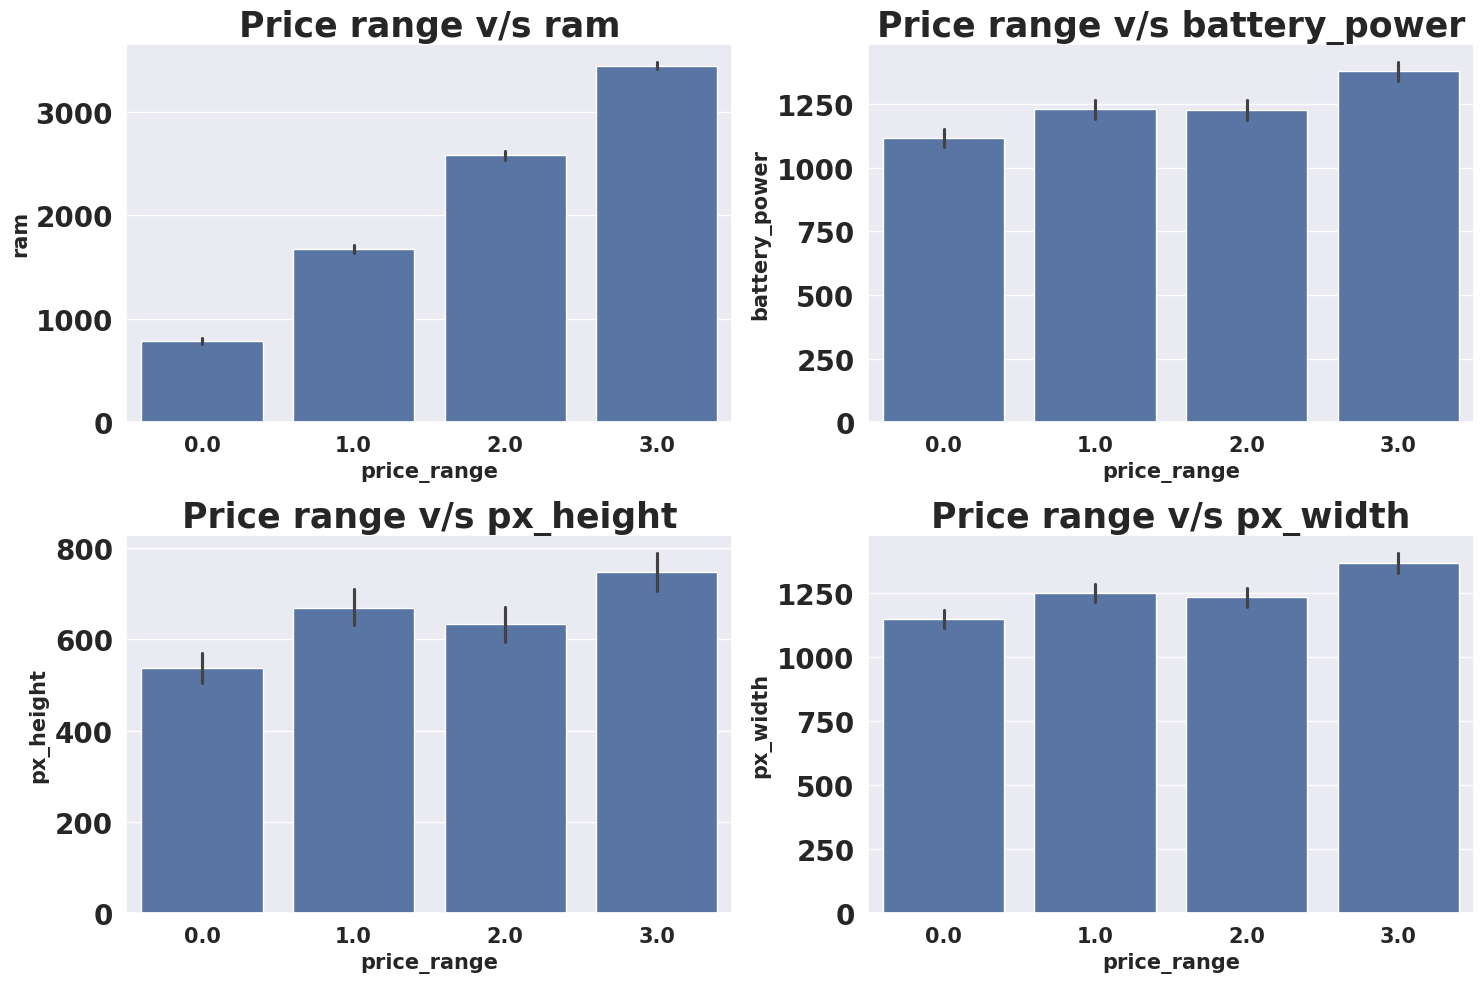

In [ ]:
# Plotting price_range vs other features
plt.figure(figsize=(15,10))

labels=['0=low cost','1=medium cost','2=high cost','3=very high cost']
rows=2
col=2
counter=1

variables=['ram','battery_power','px_height','px_width']
for var in variables:
  plt.subplot(rows,col,counter)
  sns.barplot(x=mobile_data['price_range'],y=mobile_data[var])
  plt.title(f'Price range v/s {var}')
  counter=counter+1
  plt.tight_layout()


# **Observations:**
       

*   Mobiles having RAM more tahn 3000MB falls under Very high cost category.As RAM increases price range also increases.

*  Mobiles having RAM less than 1000 MB falls under low cost category.
*   Mobiles with battery power more than 1300 mAh has very high cost.And mobiles with battery power between 1200 mAh falls under medium and high cost category.


*  Mobiles with more than 700 pixel height and width more than 1300 has very high cost.



In [ ]:
#  Checking the counts of binary categorical variables by grouping price range.
grup_by_price=mobile_data.groupby(['price_range']).agg({'blue':'value_counts','dual_sim':'value_counts','four_g':'value_counts','three_g':'value_counts','wifi':'value_counts','touch_screen':'value_counts'})

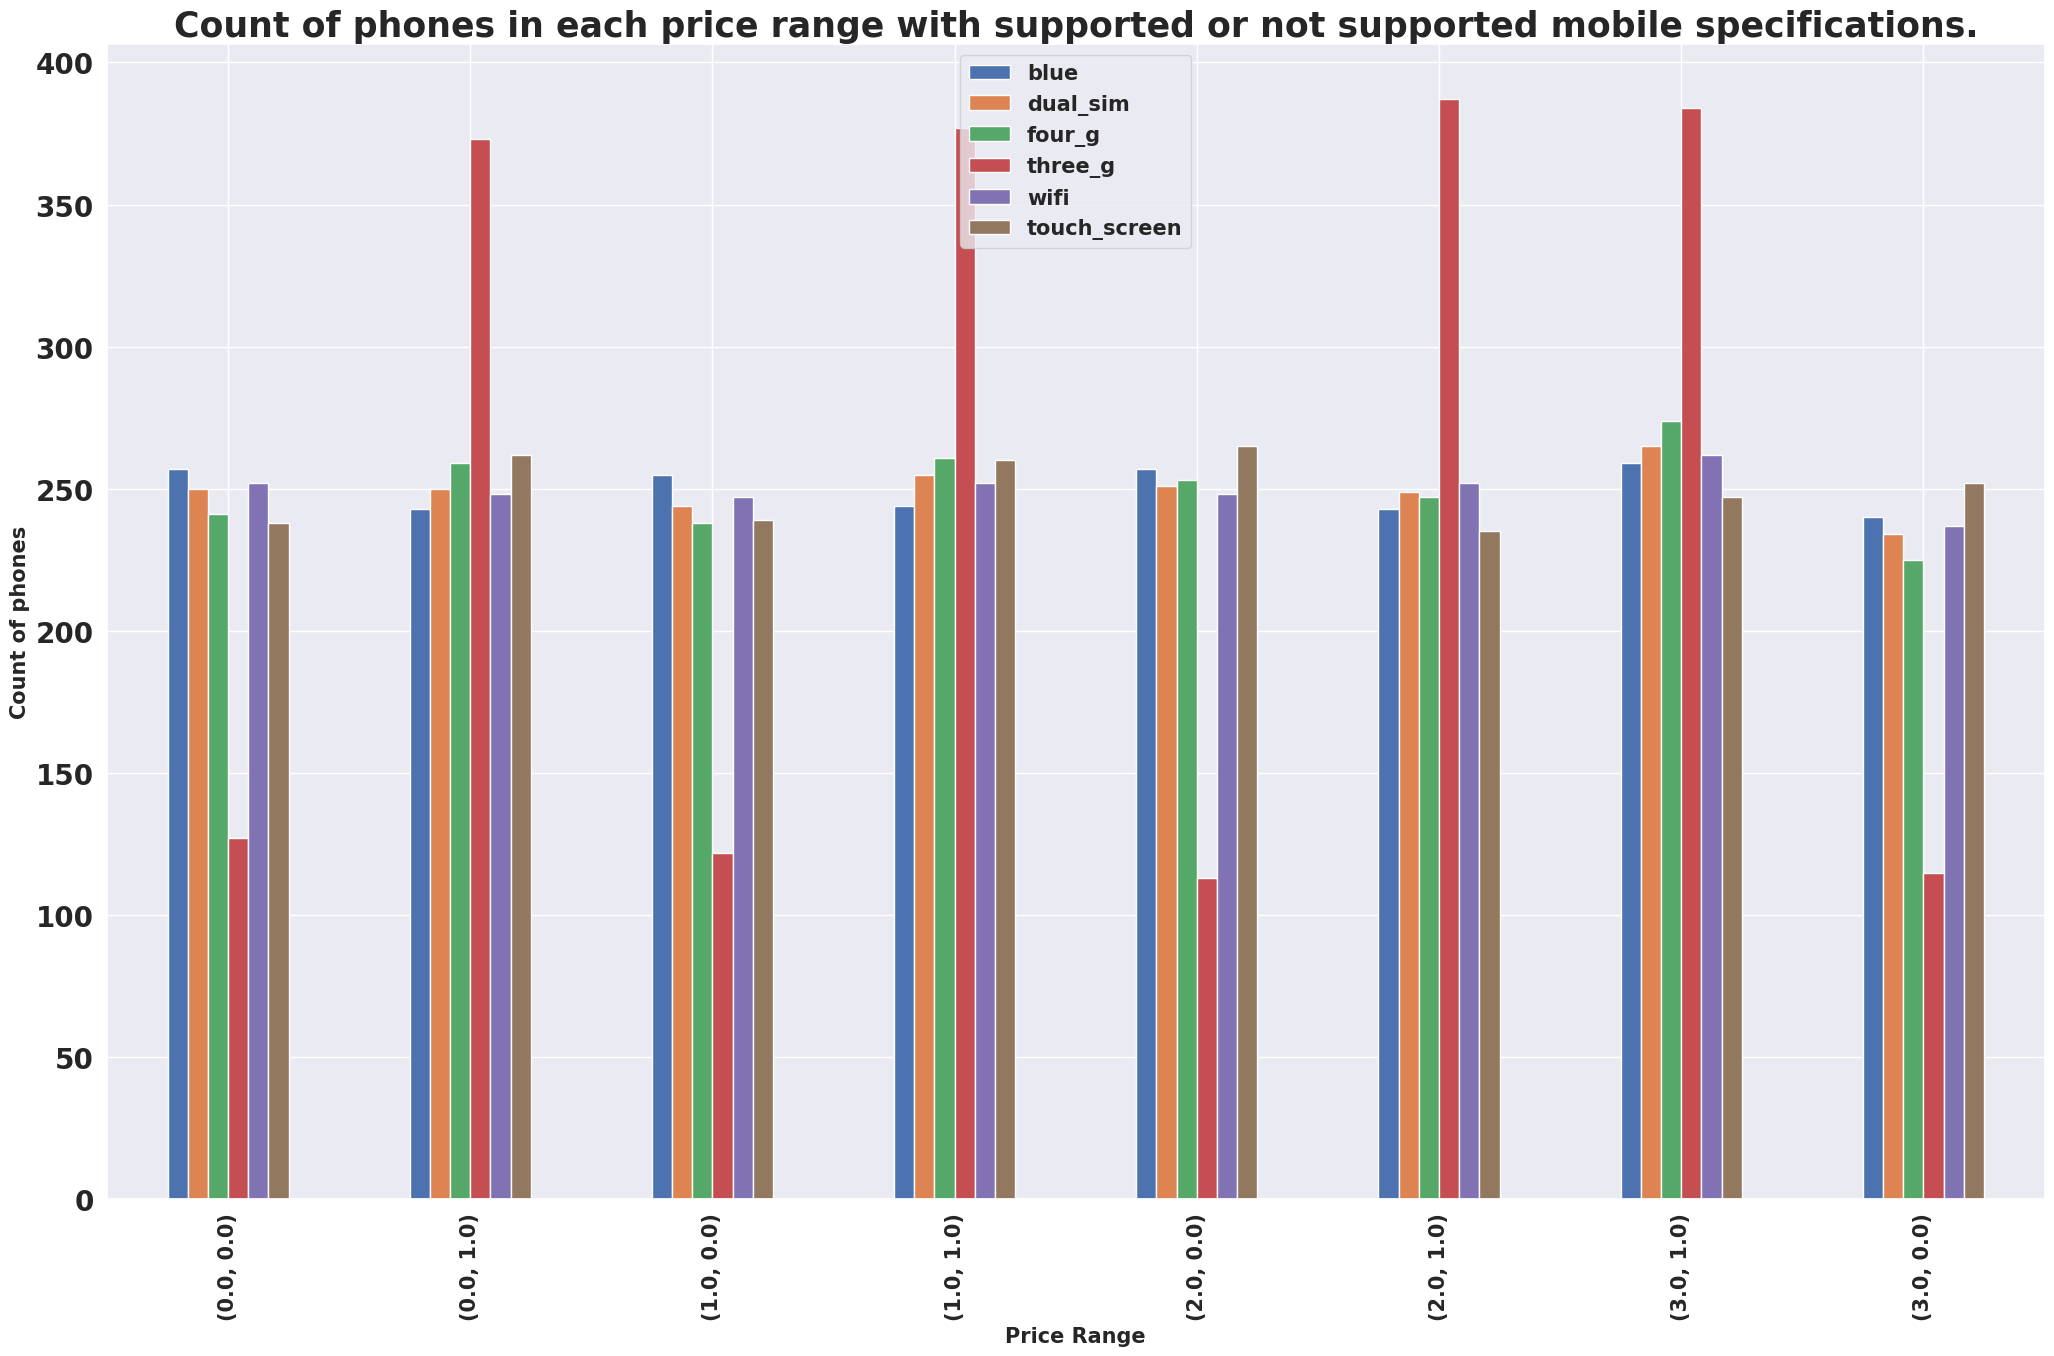

In [ ]:
# visualing by plotting barchat.
# plt.figure(figsize=(12,16))
grup_by_price.plot.bar(figsize=(25,15))
plt.title('Count of phones in each price range with supported or not supported mobile specifications.')
plt.xlabel('Price Range')
plt.ylabel('Count of phones')
plt.legend(loc='upper center')

# **Observations**
We can see that each price range category has equal number of mobiles phones having both supporting and non supporting specifications.

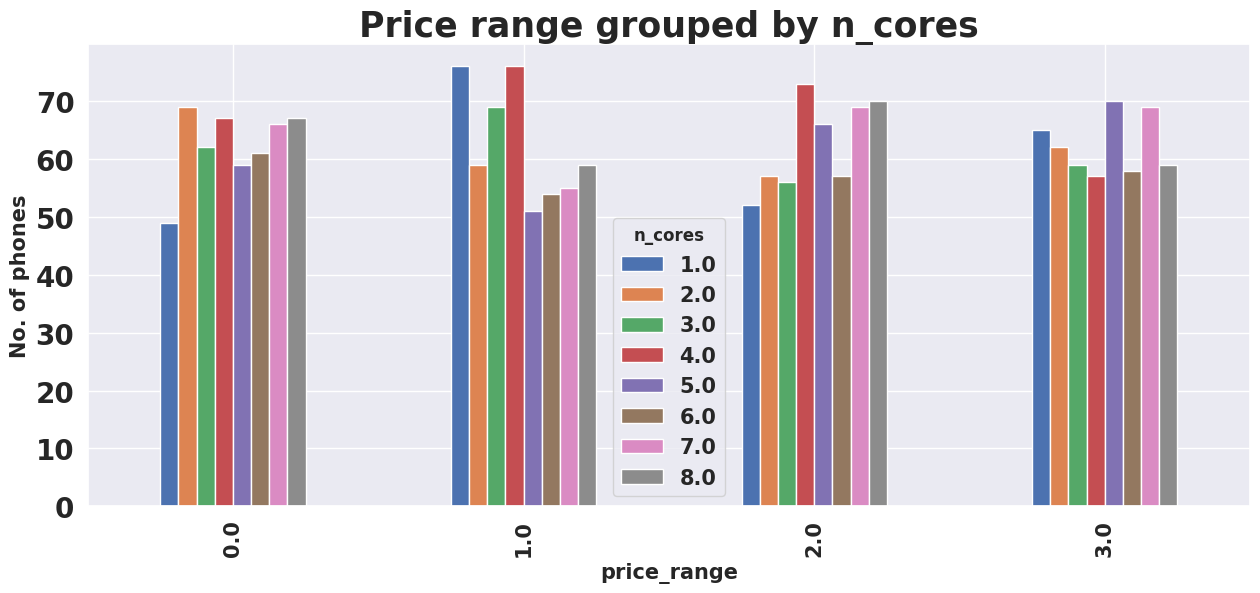

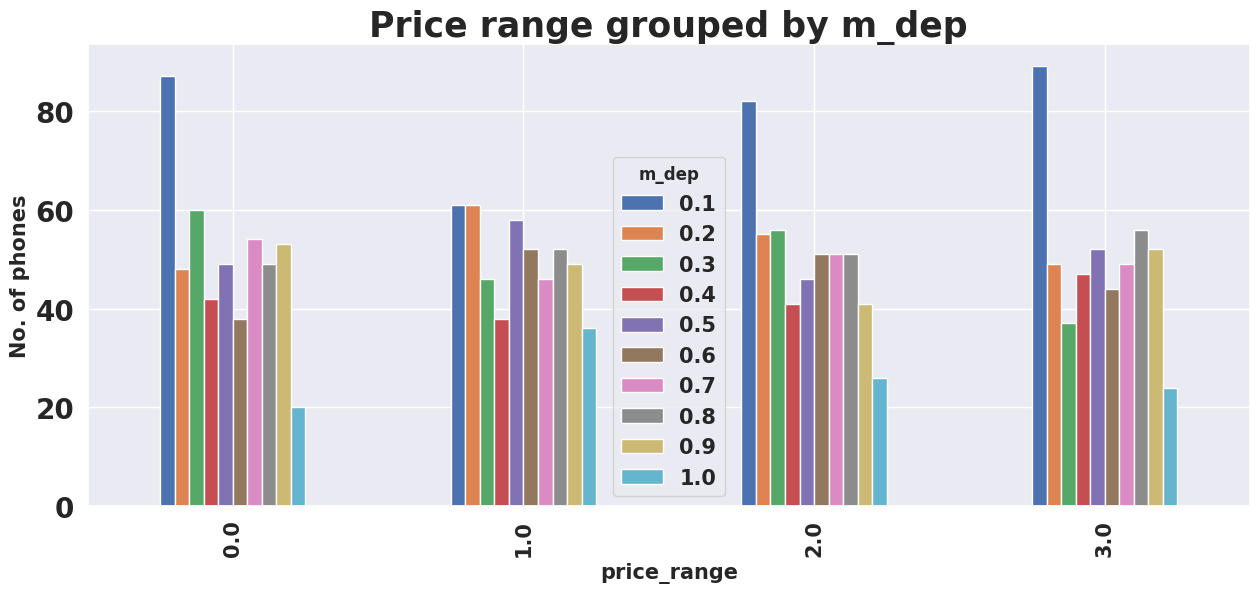

In [ ]:
list_2=['n_cores','m_dep']
for item in list_2:

  mobile_data.groupby(['price_range'])[item].value_counts().unstack().plot.bar(figsize=(15,6))
  plt.title(f'Price range grouped by {item}')
  plt.ylabel('No. of phones')

## **Observation**
      

*  There are very few mobiles in price range 0 and 1 with lesser no of cores.

*   Most of the mobiles in price range 2 and 3 are with high no of cores.

*  Number of phones with less thickness is high and count of phones with high thickness is low.



# **Let's Check which numerical feature is driving the price range most.**

In [ ]:
mobile_data.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

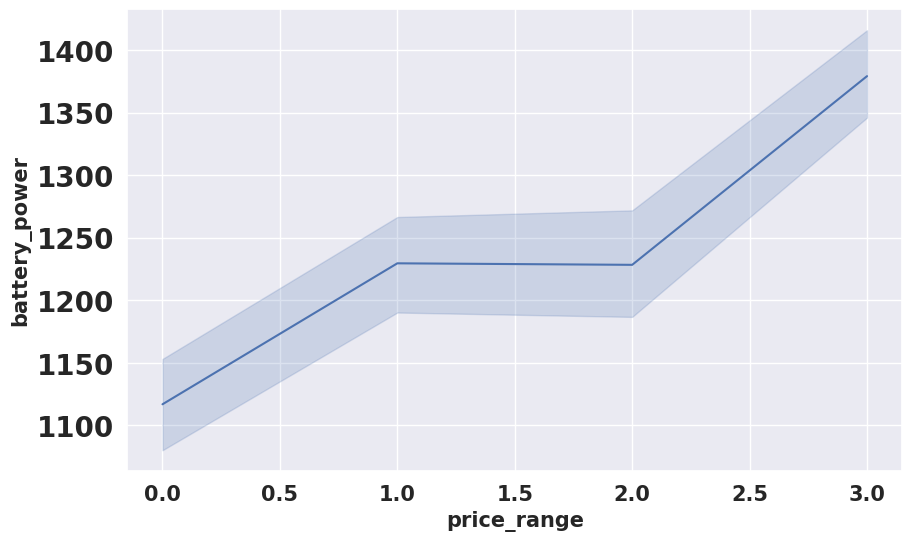

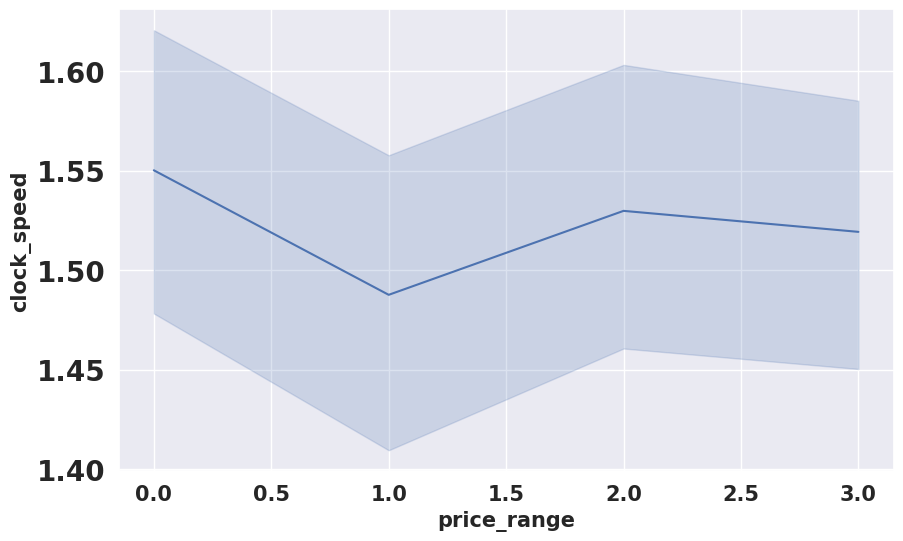

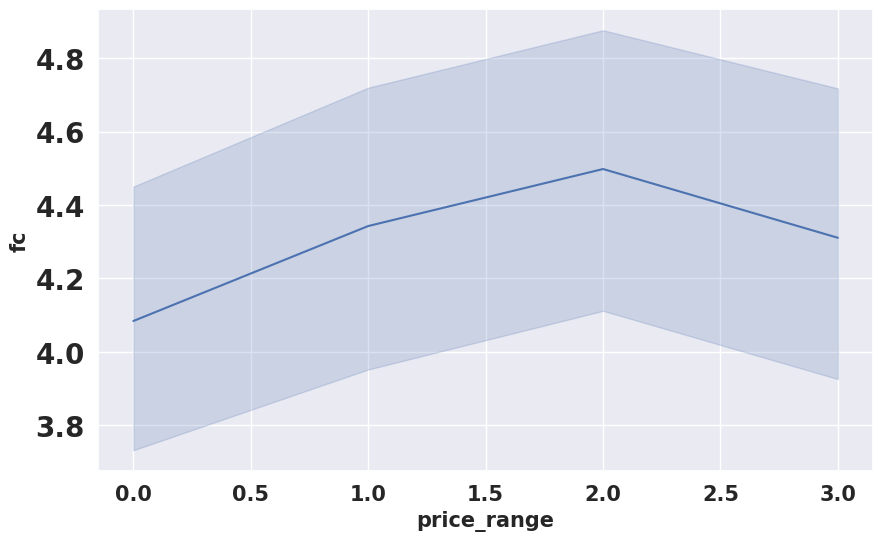

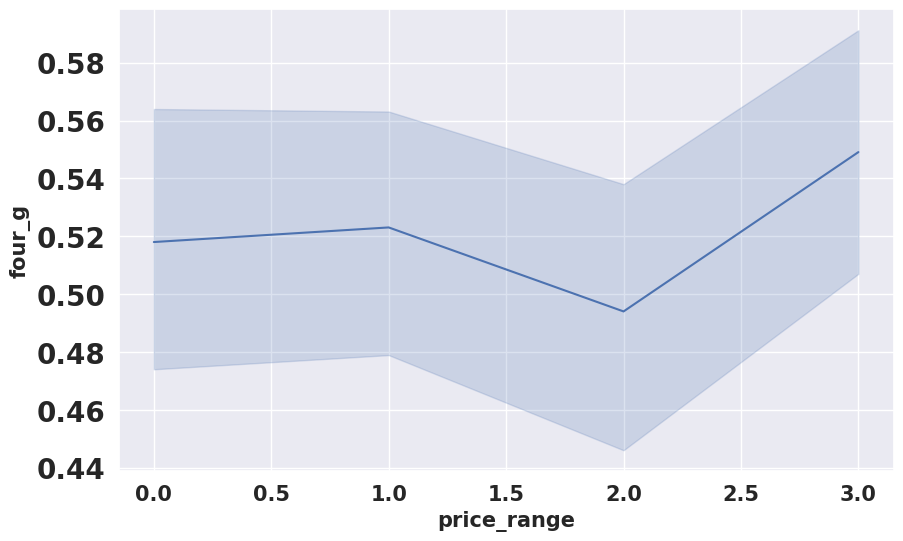

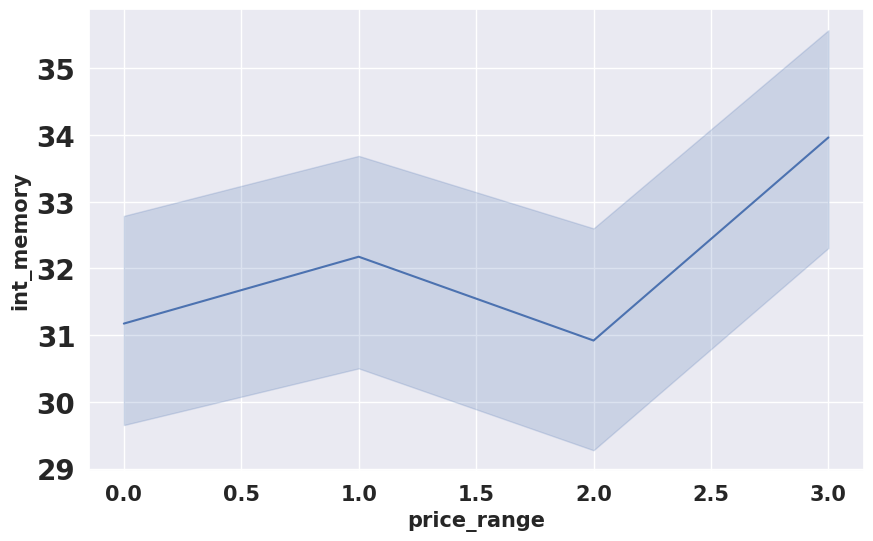

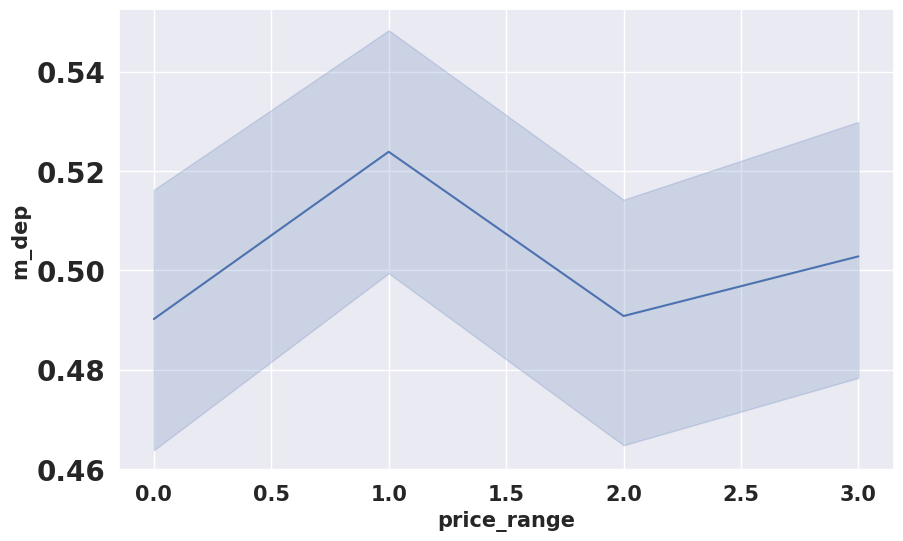

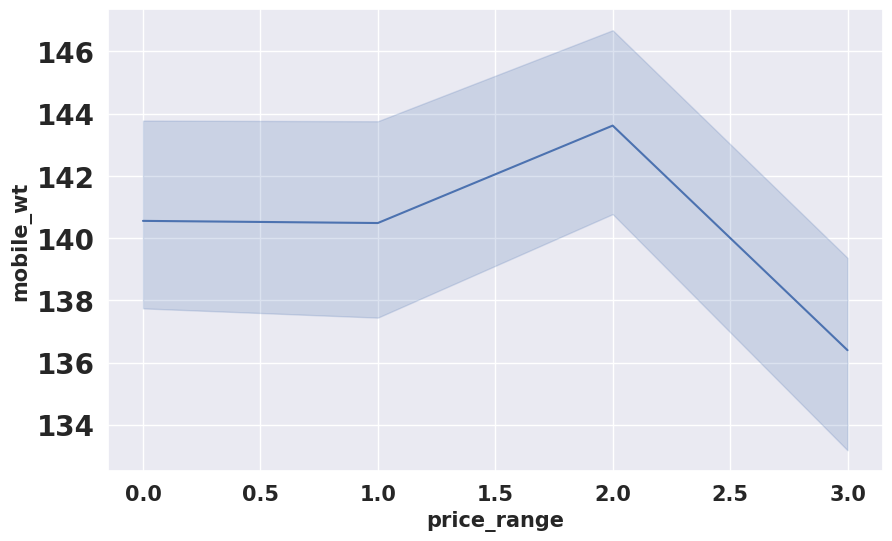

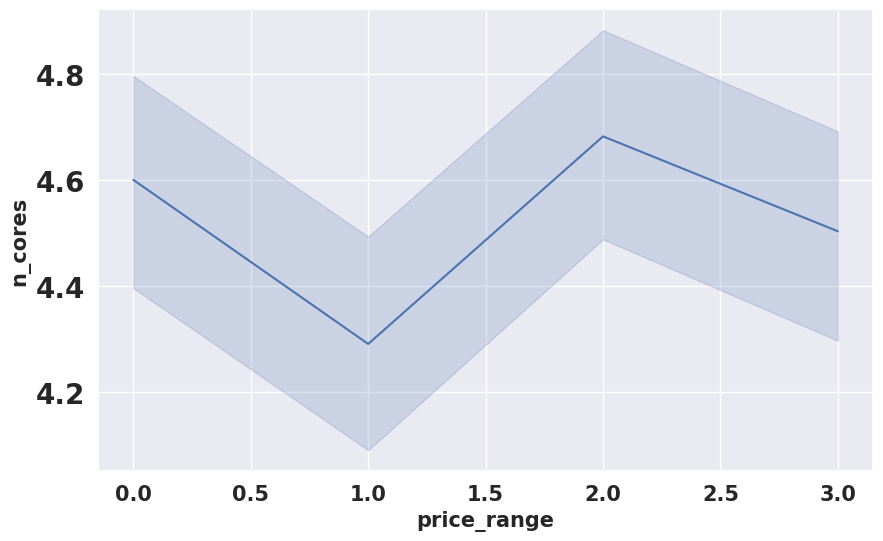

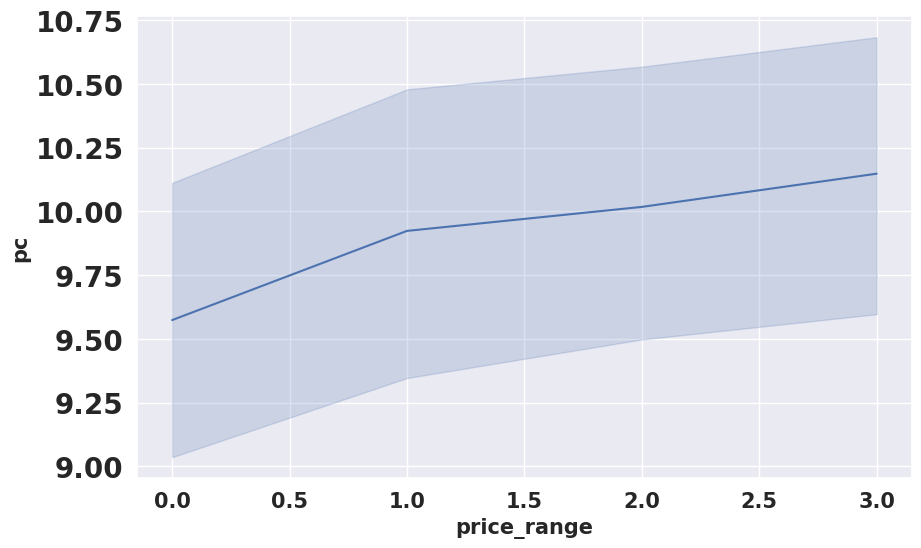

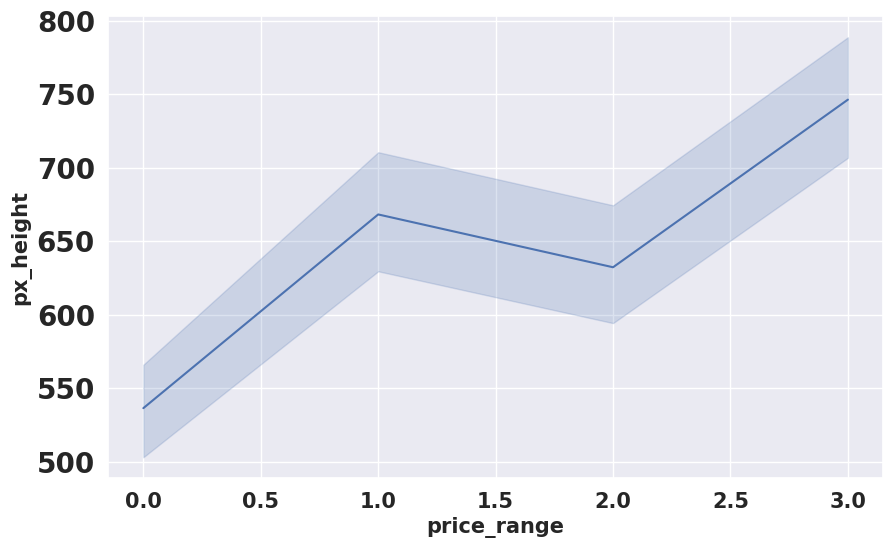

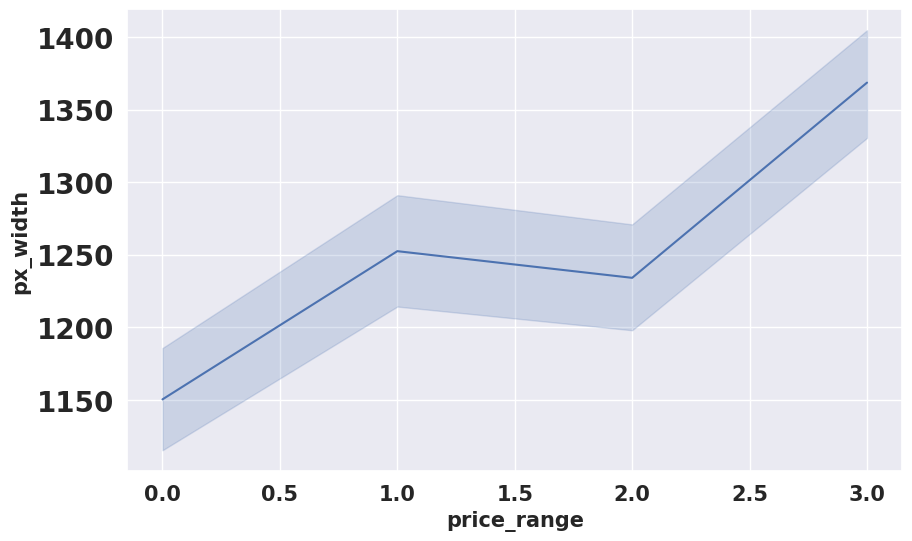

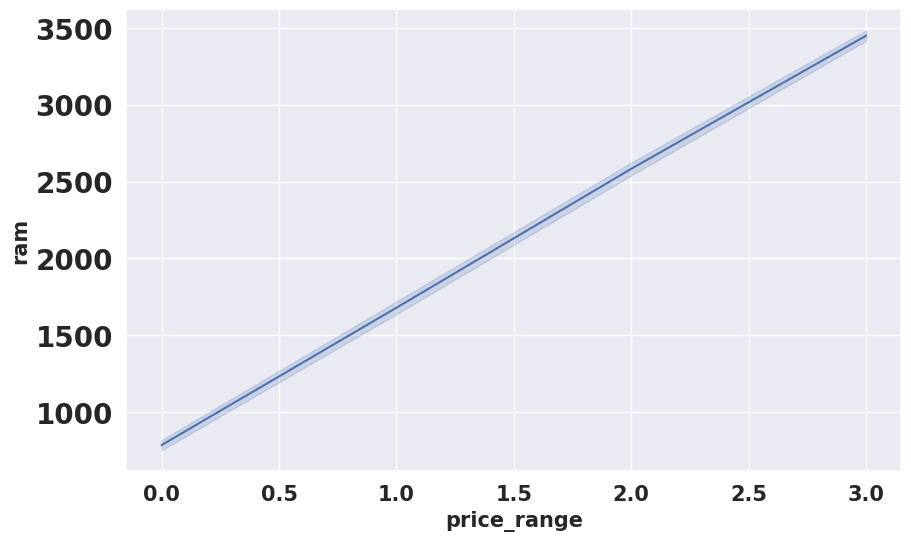

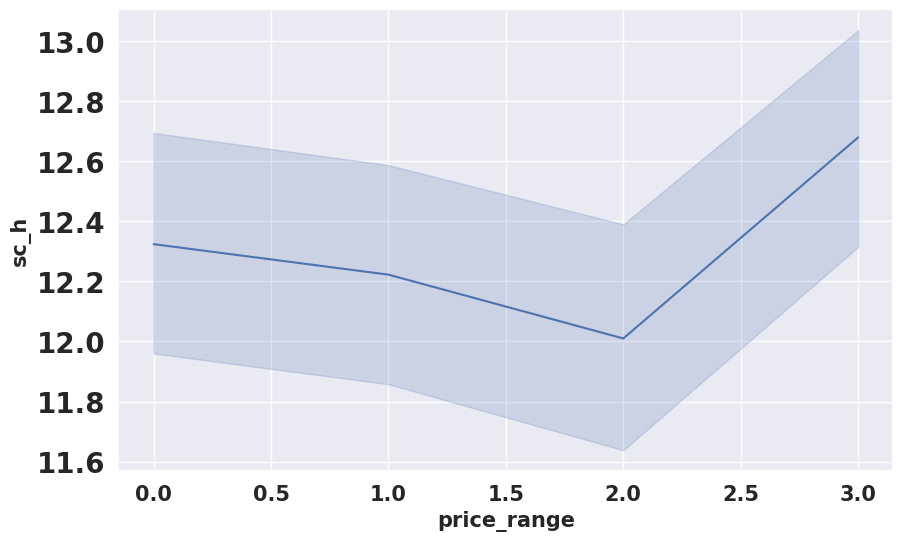

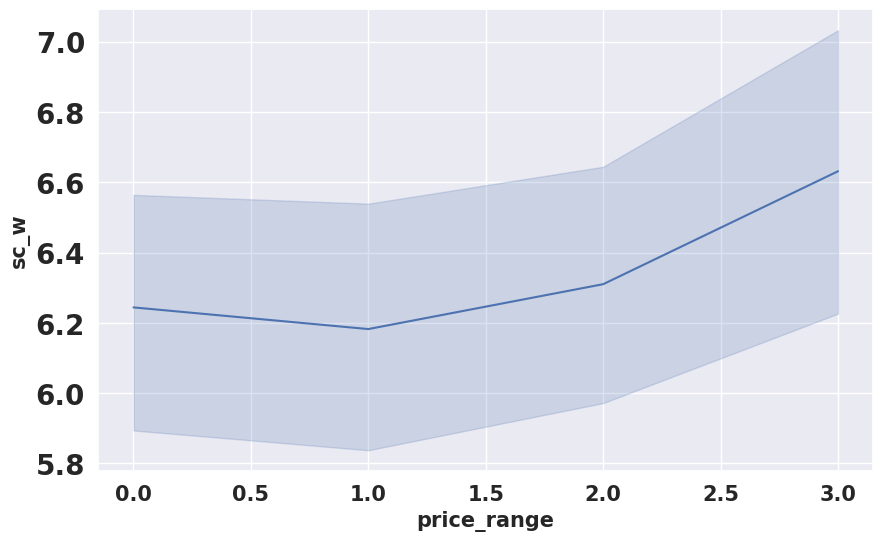

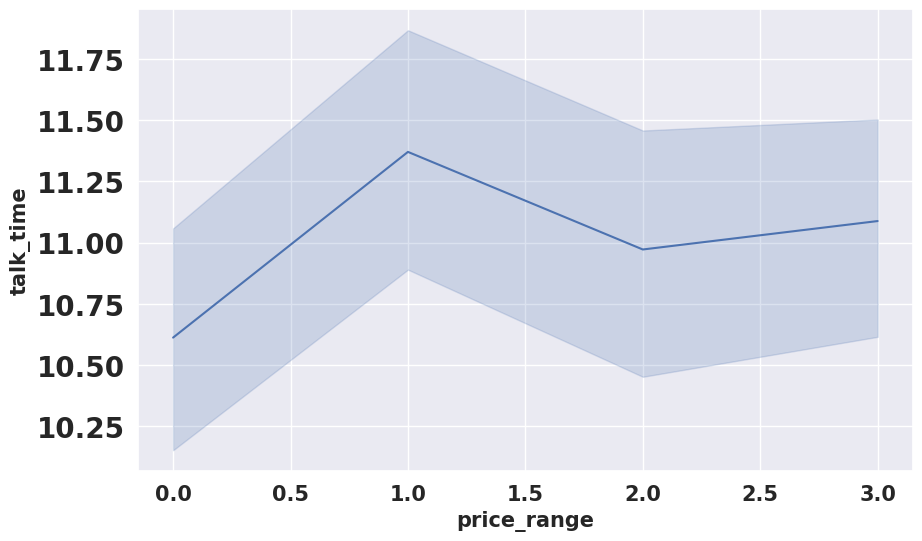

In [ ]:
list_1=['battery_power','clock_speed','fc','four_g','int_memory','m_dep','mobile_wt','n_cores','pc','px_height','px_width','ram','sc_h','sc_w','talk_time']
# plotting boxplot and distribution
counter=1
for var in list_1:
  plt.figure(figsize=(10,6))

  sns.lineplot(x=mobile_data['price_range'],y=mobile_data[var])


# **Observations**
       

*   For class 1 and class 2 battery power range is almost similar.As battery power increases price also increases which is quite obivious.

*   Mobiles is very high price range(Ckass 3)has less weight compared to other calsses.That means of mobiles drcrease price increases.
*   Mobiles having max screen height and width falls in very high high price category.We can see in linechart of sc_width and sc_height from class 2 screen width and hwight starts increasisng with price.Similar case is with px_height and px_width.As resolution of screen increases the price also increases


*   RAM has clear relationship with price range we swa that in correlation matrix also.



# **Mobiles with both 3G and 4G**

In [ ]:
# Filter for mobiles with both 3G and 4G
mobiles_with_3g_and_4g = mobile_data[(mobile_data['three_g'] == 1) & (mobile_data['four_g'] == 1)]
display(mobiles_with_3g_and_4g.head())

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1,1021.0,1.0,0.5,1.0,0.0,1.0,53.0,0.7,136.0,3.0,6.0,905.0,1988.0,2631.0,17.0,3.0,7.0,1.0,1.0,0.0,2.0
2,563.0,1.0,0.5,1.0,2.0,1.0,41.0,0.9,145.0,5.0,6.0,1263.0,1716.0,2603.0,11.0,2.0,9.0,1.0,1.0,0.0,2.0
4,1821.0,1.0,1.2,0.0,13.0,1.0,44.0,0.6,141.0,2.0,14.0,1208.0,1212.0,1411.0,8.0,2.0,15.0,1.0,1.0,0.0,1.0
6,1821.0,0.0,1.7,0.0,4.0,1.0,10.0,0.8,139.0,8.0,10.0,381.0,1018.0,3220.0,13.0,8.0,18.0,1.0,0.0,1.0,3.0
9,509.0,1.0,0.6,1.0,2.0,1.0,9.0,0.1,93.0,5.0,15.0,1137.0,1224.0,513.0,19.0,10.0,12.0,1.0,0.0,0.0,0.0


# **Mobiles with 3G**

In [ ]:
# Filter for mobiles with both 3G
mobiles_with_3g =  mobile_data[(mobile_data['three_g'] == 1)]
display(mobiles_with_3g.head)

<bound method NDFrame.head of       battery_power  blue  clock_speed  dual_sim    fc  four_g  int_memory  \
1            1021.0   1.0          0.5       1.0   0.0     1.0        53.0   
2             563.0   1.0          0.5       1.0   2.0     1.0        41.0   
3             615.0   1.0          2.5       0.0   0.0     0.0        10.0   
4            1821.0   1.0          1.2       0.0  13.0     1.0        44.0   
5            1859.0   0.0          0.5       1.0   3.0     0.0        22.0   
...             ...   ...          ...       ...   ...     ...         ...   
1993          794.0   1.0          0.5       1.0   0.0     1.0         2.0   
1994         1965.0   1.0          2.6       1.0   0.0     0.0        39.0   
1995         1911.0   0.0          0.9       1.0   1.0     1.0        36.0   
1996         1512.0   0.0          0.9       0.0   4.0     1.0        46.0   
1997          510.0   1.0          2.0       1.0   5.0     1.0        45.0   

      m_dep  mobile_wt  n_cores    pc  px_height  px_width     ram  sc_h  \
1       0.7      136.0      3.0   6.0      905.0    1988.0  2631.0  17.0   
2       0.9      145.0      5.0   6.0     1263.0    1716.0  2603.0  11.0   
3       0.8      131.0      6.0   9.0     1216.0    1786.0  2769.0  16.0   
4       0.6      141.0      2.0  14.0     1208.0    1212.0  1411.0   8.0   
5       0.7      164.0      1.0   7.0     1004.0    1654.0  1067.0  17.0   
...     ...        ...      ...   ...        ...       ...     ...   ...   
1993    0.8      106.0      6.0  14.0     1222.0    1890.0   668.0  13.0   
1994    0.2      187.0      4.0   3.0      915.0    1965.0  2032.0  11.0   
1995    0.7      108.0      8.0   3.0      868.0    1632.0  3057.0   9.0   
1996    0.1      145.0      5.0   5.0      336.0     670.0   869.0  18.0   
1997    0.9      168.0      6.0  16.0      483.0     754.0  3919.0  19.0   

      sc_w  talk_time  three_g  touch_screen  wifi  price_range  
1      3.0        7.0      1.0           1.0   0.0          2.0  
2      2.0        9.0      1.0           1.0   0.0          2.0  
3      8.0       11.0      1.0           0.0   0.0          2.0  
4      2.0       15.0      1.0           1.0   0.0          1.0  
5      1.0       10.0      1.0           0.0   0.0          1.0  
...    ...        ...      ...           ...   ...          ...  
1993   4.0       19.0      1.0           1.0   0.0          0.0  
1994  10.0       16.0      1.0           1.0   1.0          2.0  
1995   1.0        5.0      1.0           1.0   0.0          3.0  
1996  10.0       19.0      1.0           1.0   1.0          0.0  
1997   4.0        2.0      1.0           1.0   1.0          3.0  

[1521 rows x 21 columns]>

# **Mobiles that does not 3G nor 4G**

In [ ]:
# Filter for mobiles that do not have 3G and do not have 4G
mobiles_without_3g_and_4g = mobile_data[(mobile_data['three_g'] == 0) & (mobile_data['four_g'] == 0)]
display(mobiles_without_3g_and_4g.head())

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842.0,0.0,2.2,0.0,1.0,0.0,7.0,0.6,188.0,2.0,2.0,20.0,756.0,2549.0,9.0,7.0,19.0,0.0,0.0,1.0,1.0
10,769.0,1.0,2.9,1.0,0.0,0.0,9.0,0.1,182.0,5.0,1.0,248.0,874.0,3946.0,5.0,2.0,7.0,0.0,0.0,0.0,3.0
19,682.0,1.0,0.5,0.0,4.0,0.0,19.0,1.0,121.0,4.0,11.0,902.0,1064.0,2337.0,11.0,1.0,18.0,0.0,1.0,1.0,1.0
22,1949.0,0.0,2.6,1.0,4.0,0.0,47.0,0.3,199.0,4.0,7.0,407.0,822.0,1433.0,11.0,5.0,20.0,0.0,0.0,1.0,1.0
30,1579.0,1.0,0.5,1.0,0.0,0.0,5.0,0.2,88.0,7.0,9.0,1358.0,1739.0,3532.0,17.0,11.0,12.0,0.0,0.0,1.0,3.0


# **Let's Check the distribution of numerical columns and Outliers.**

In [ ]:
mobile_data.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

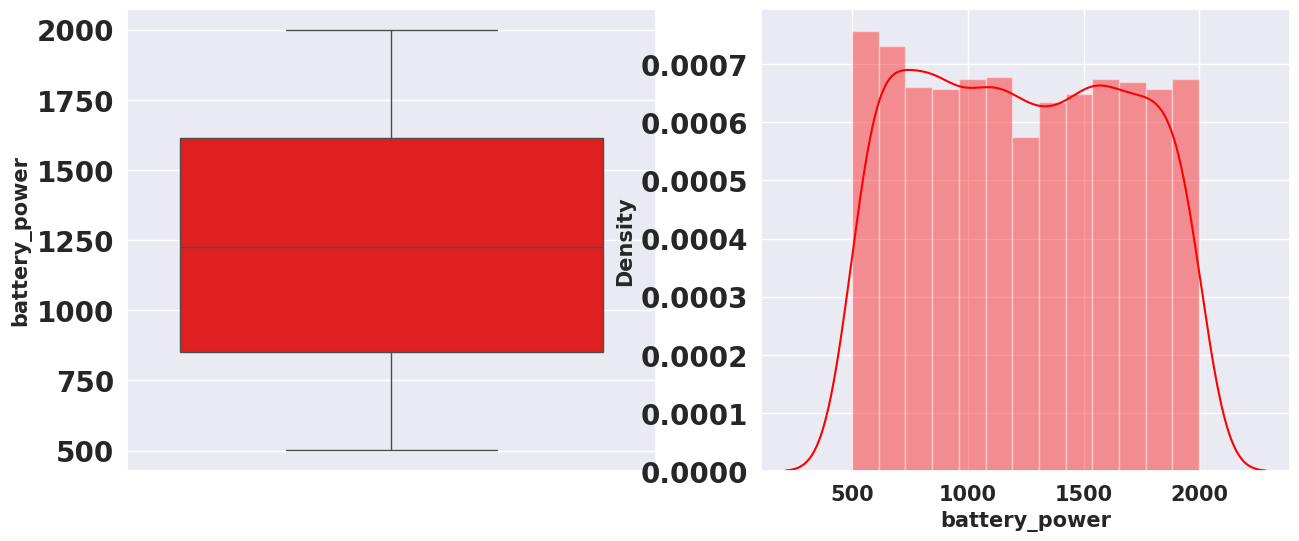

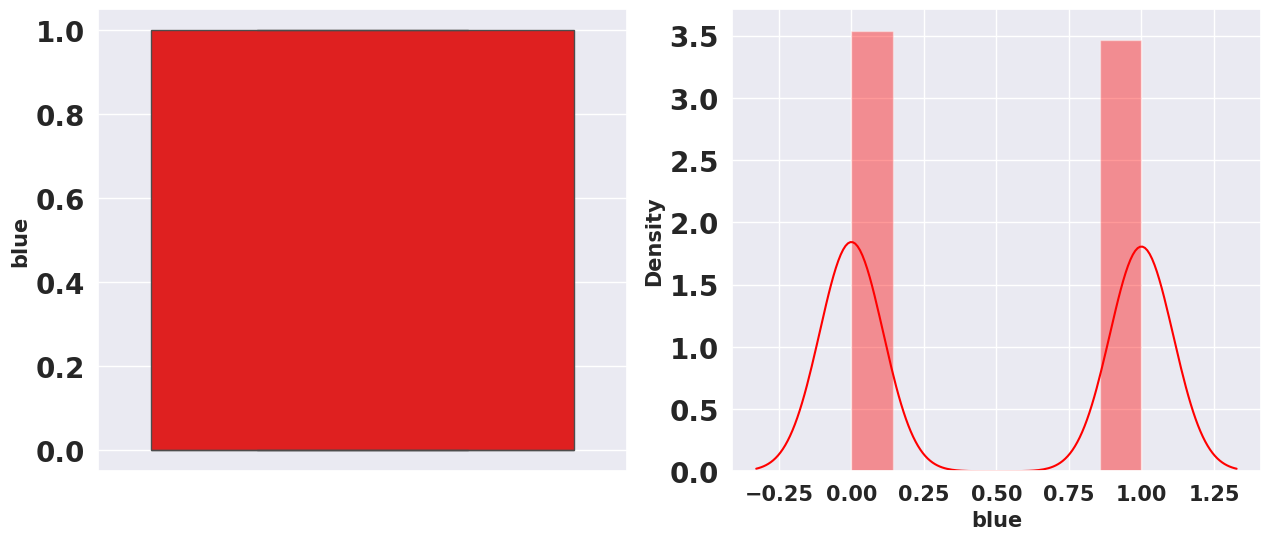

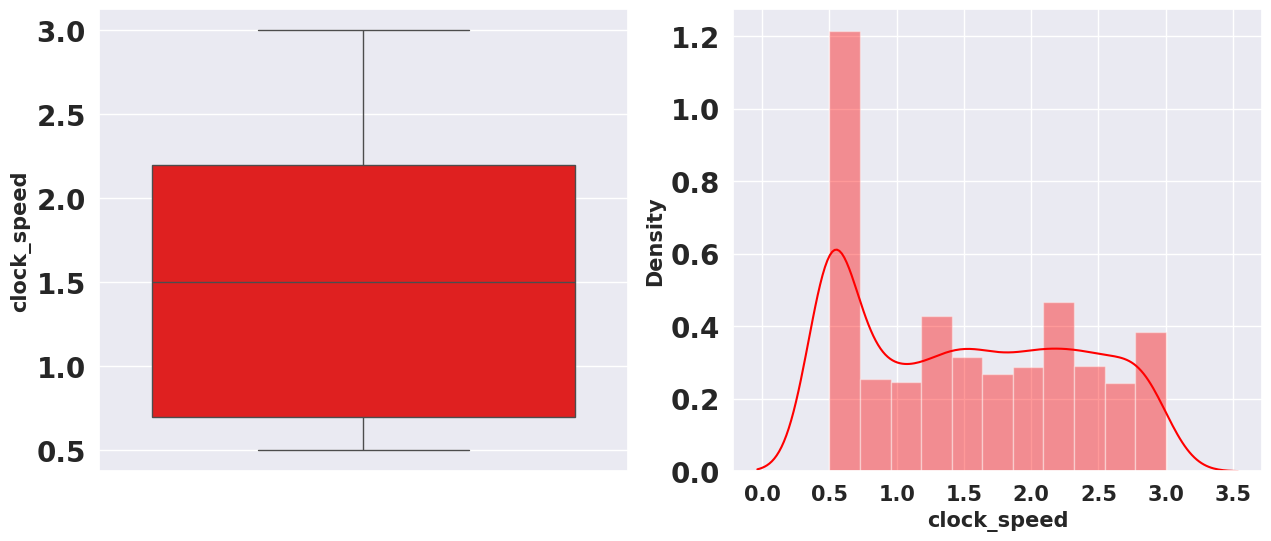

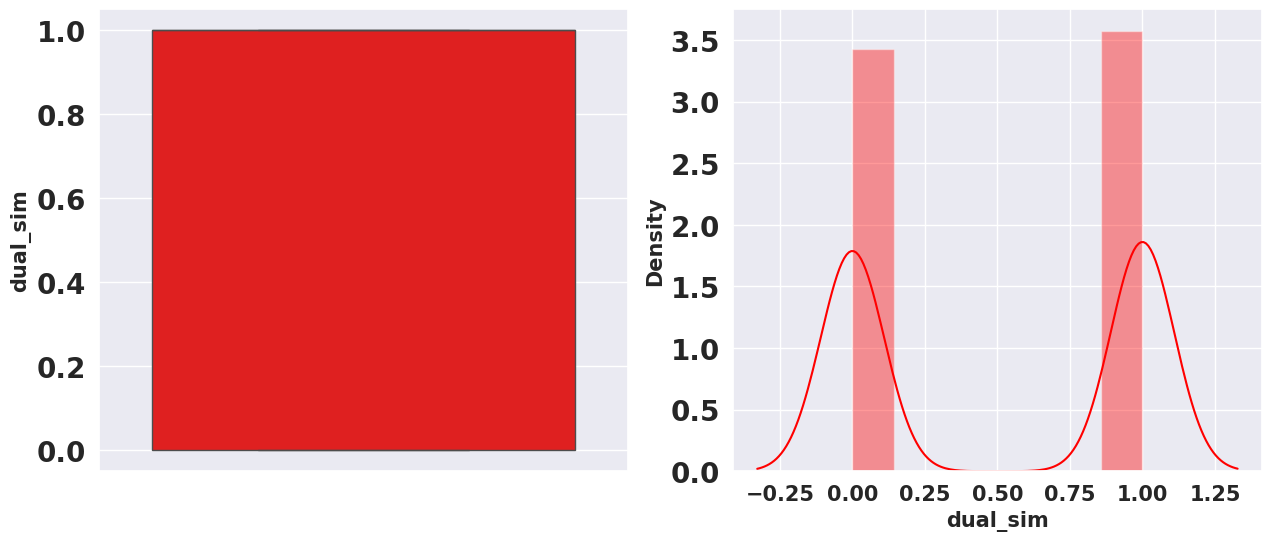

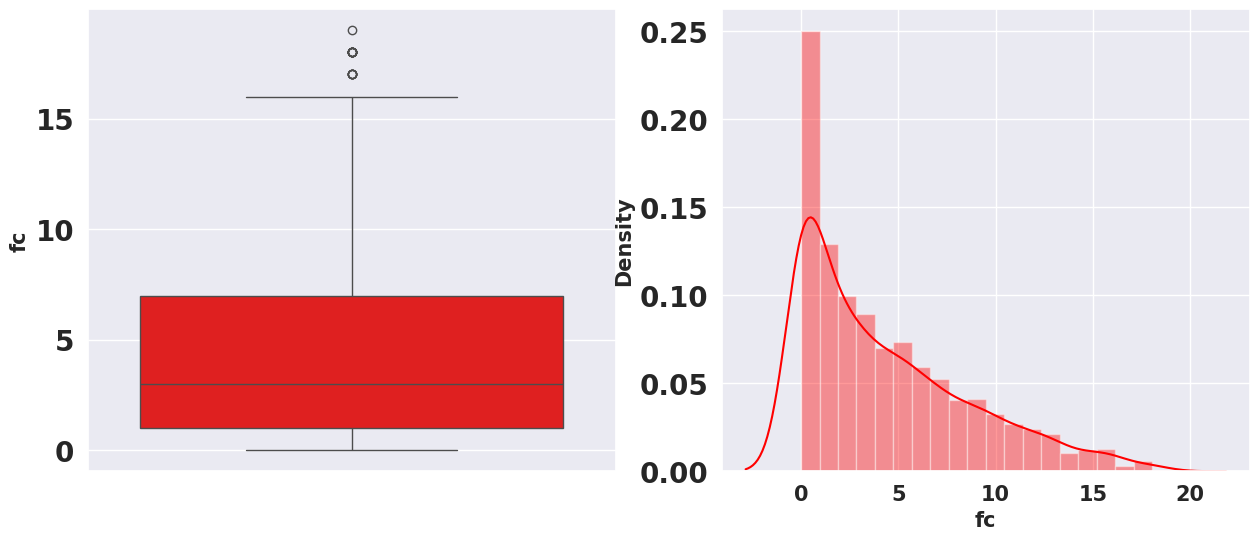

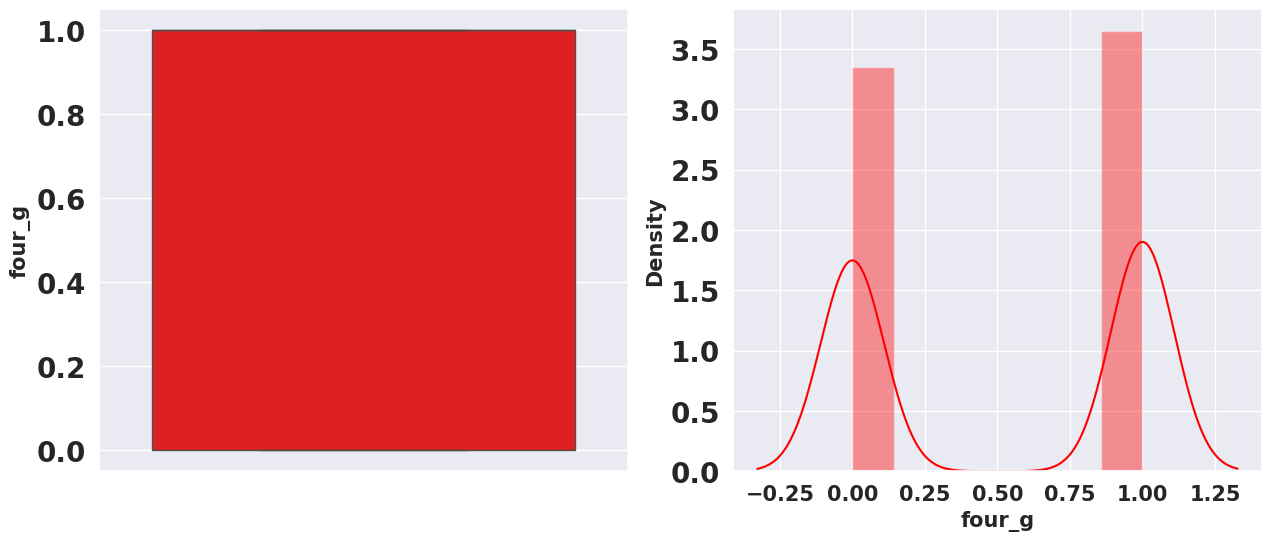

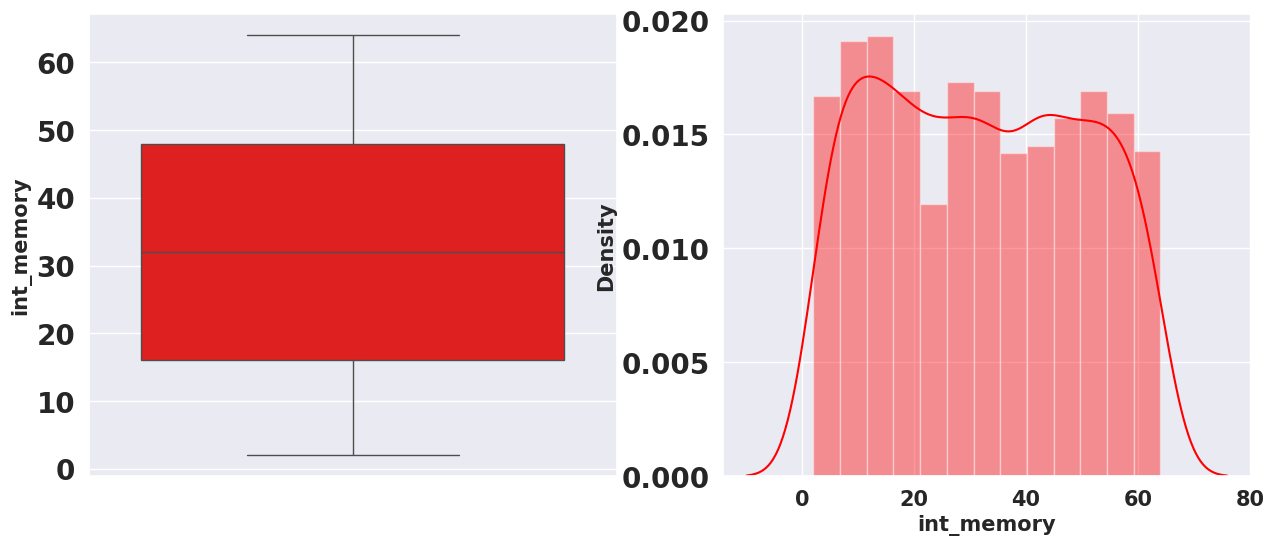

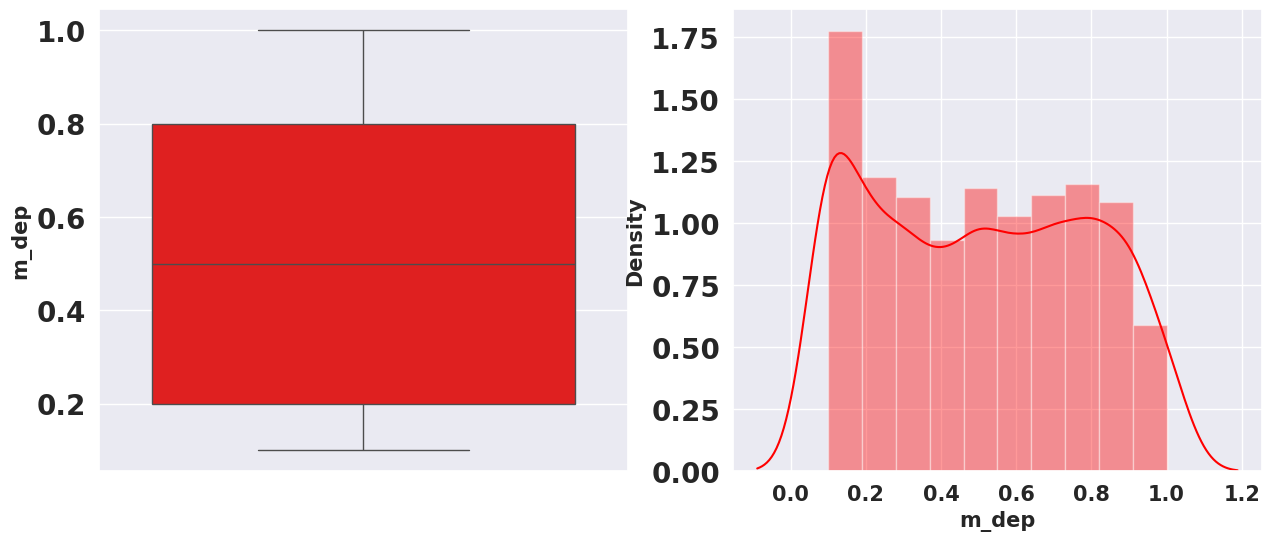

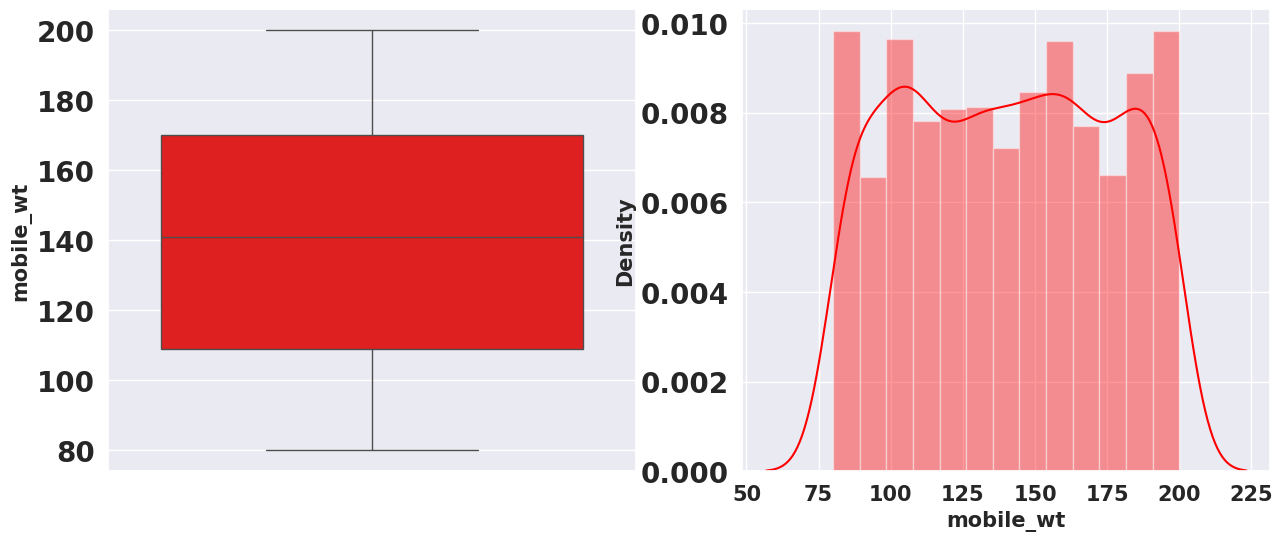

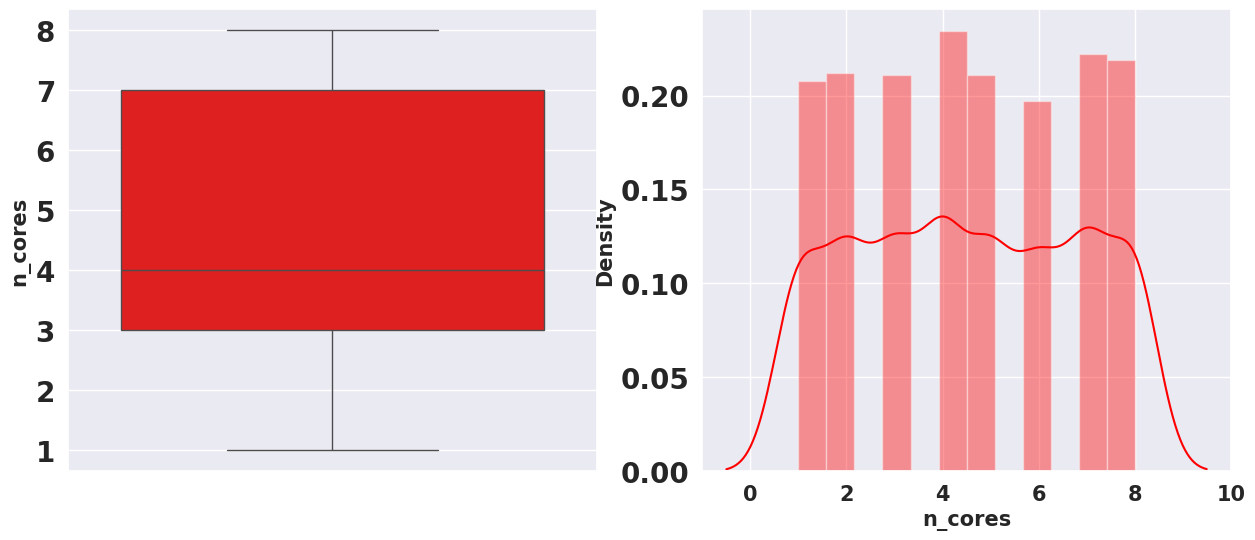

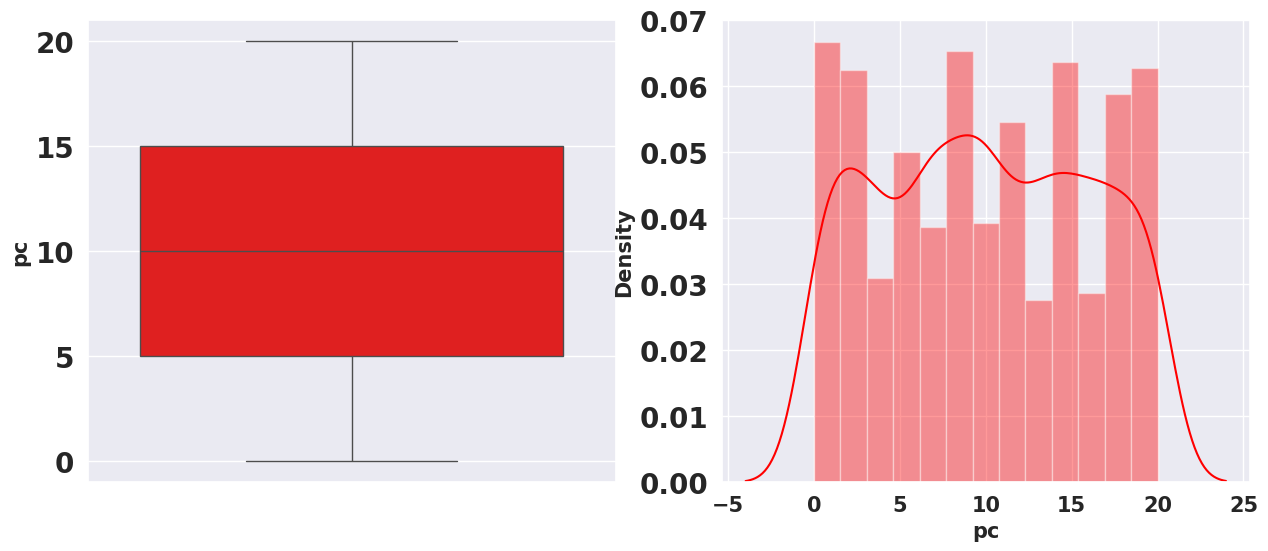

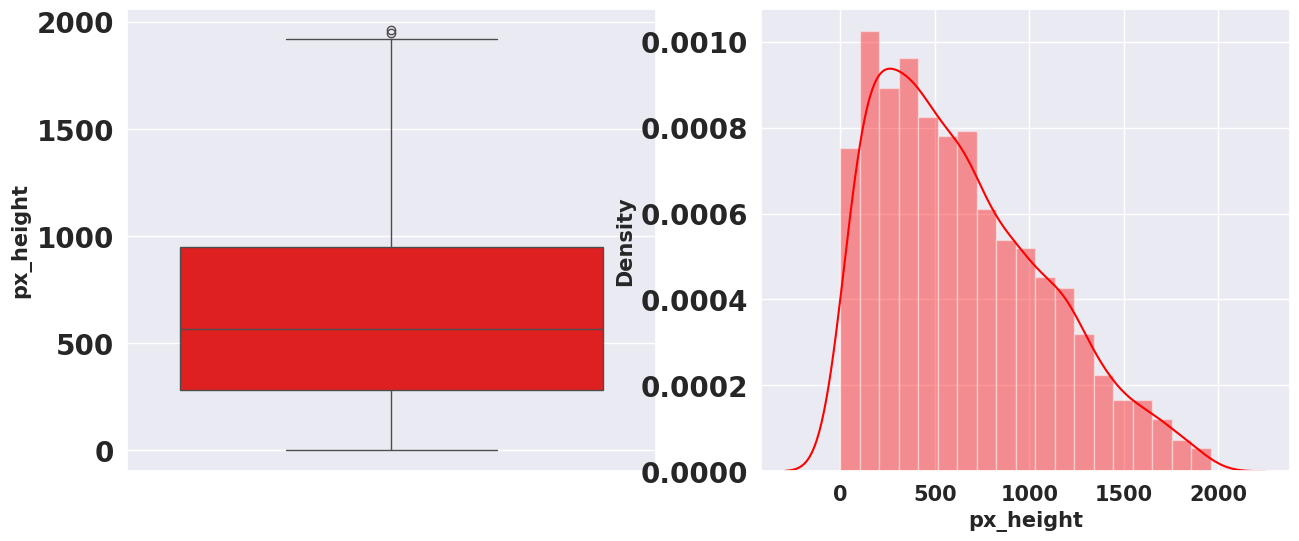

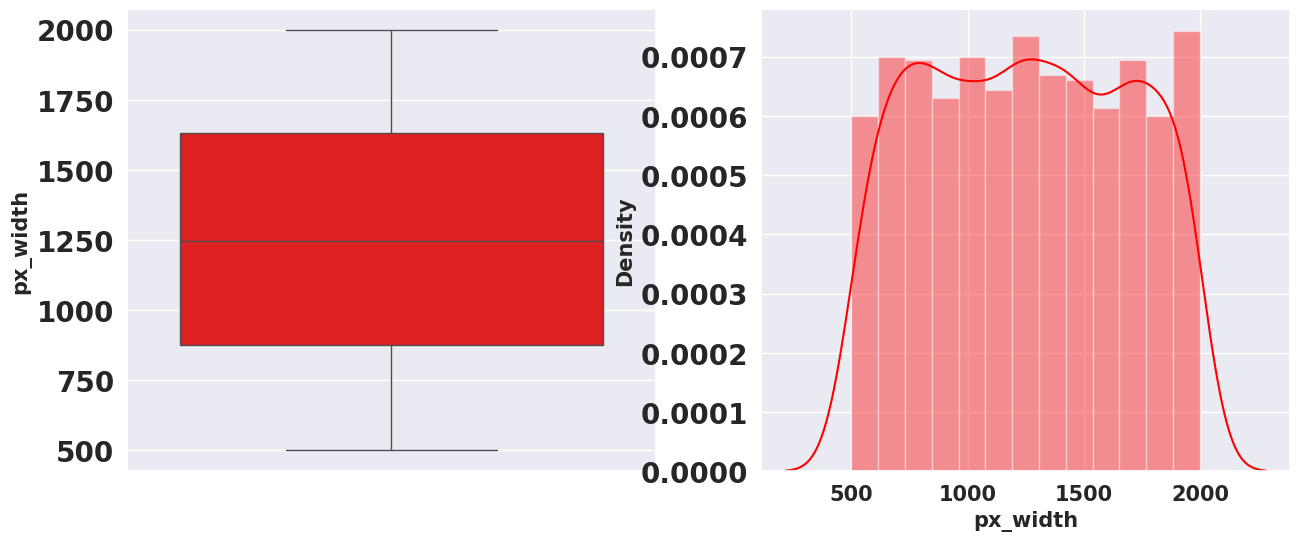

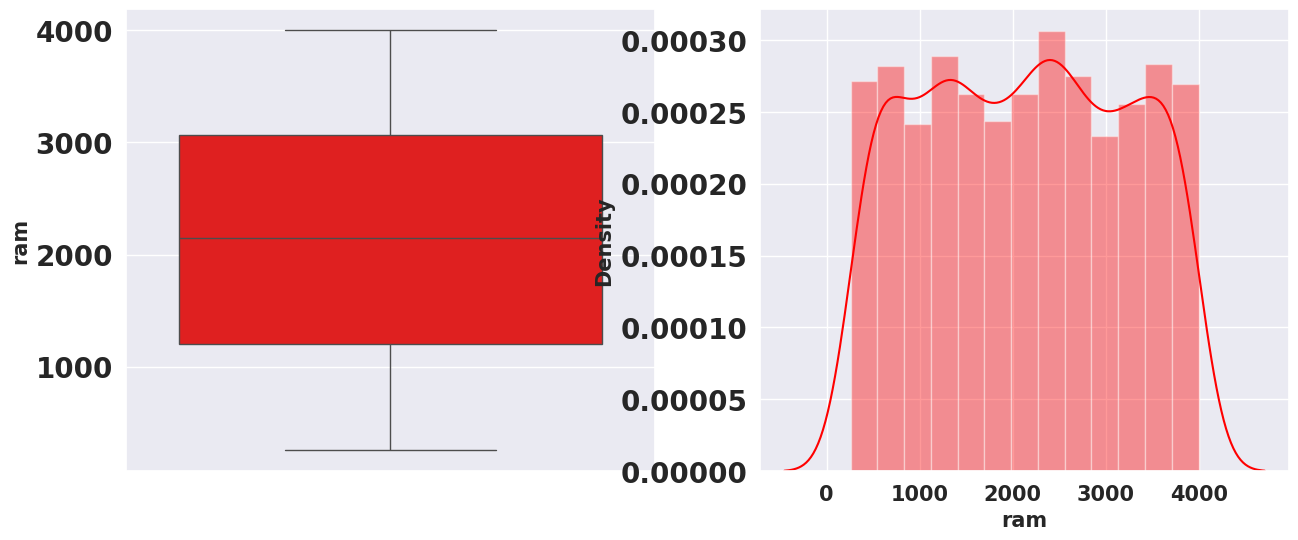

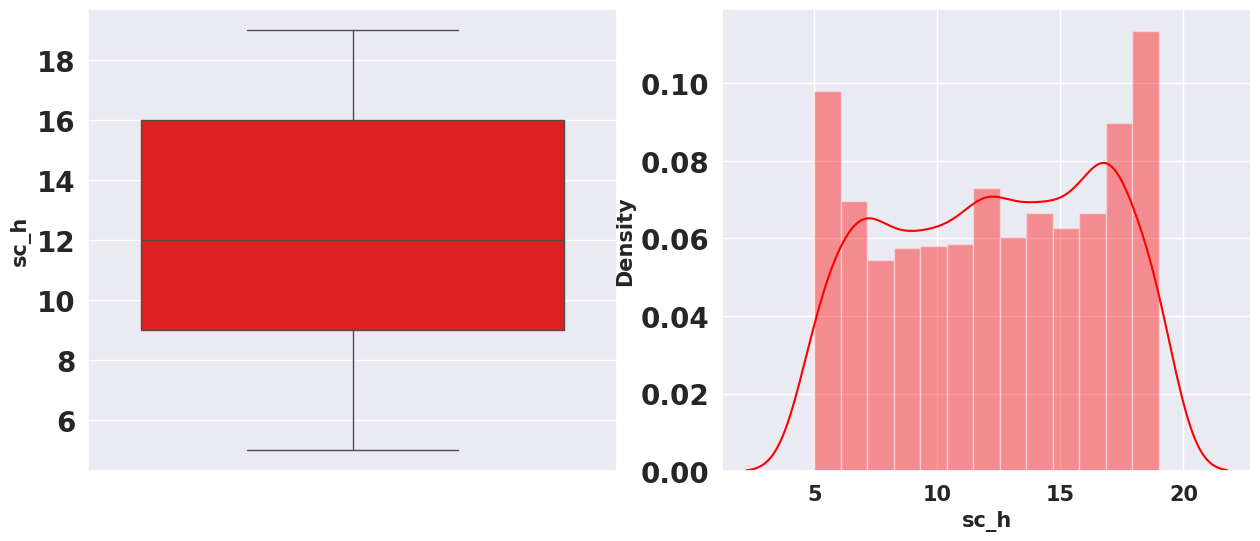

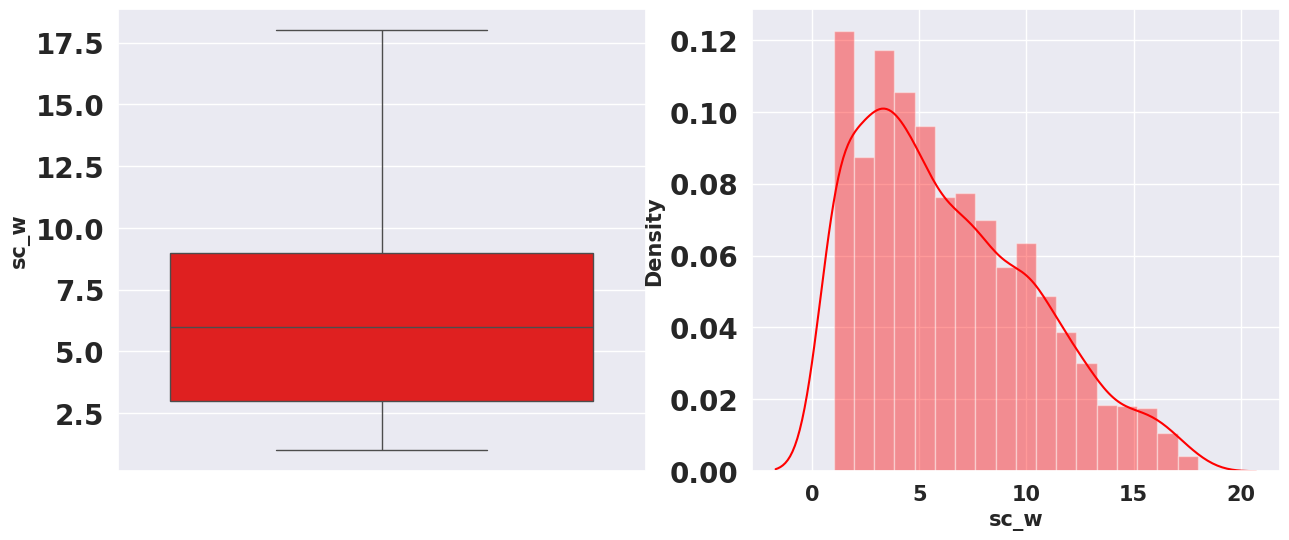

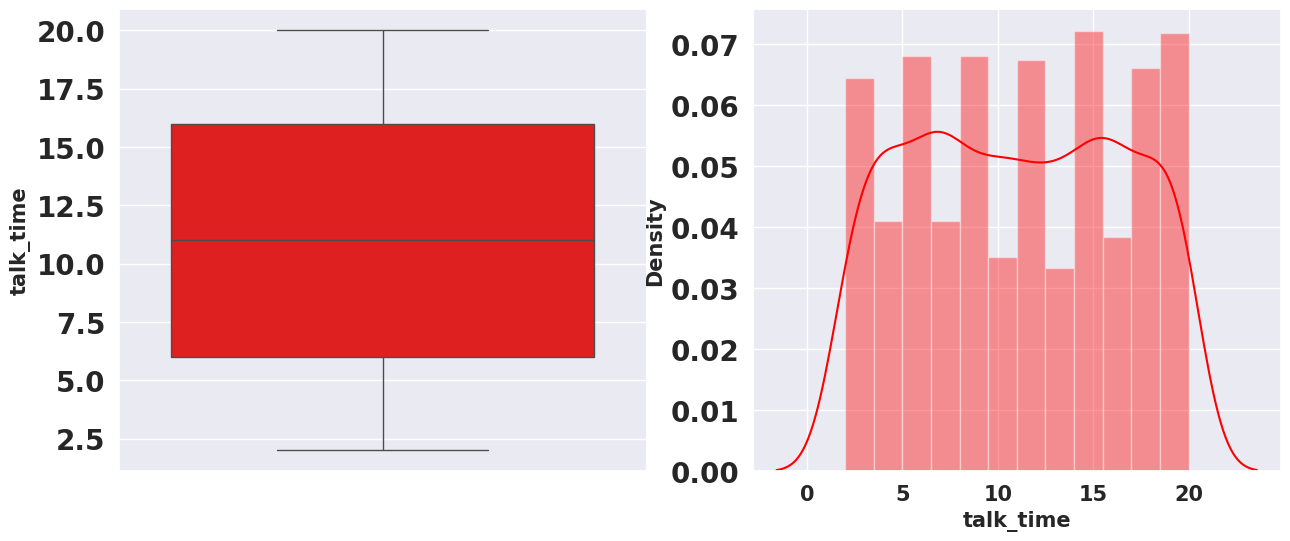

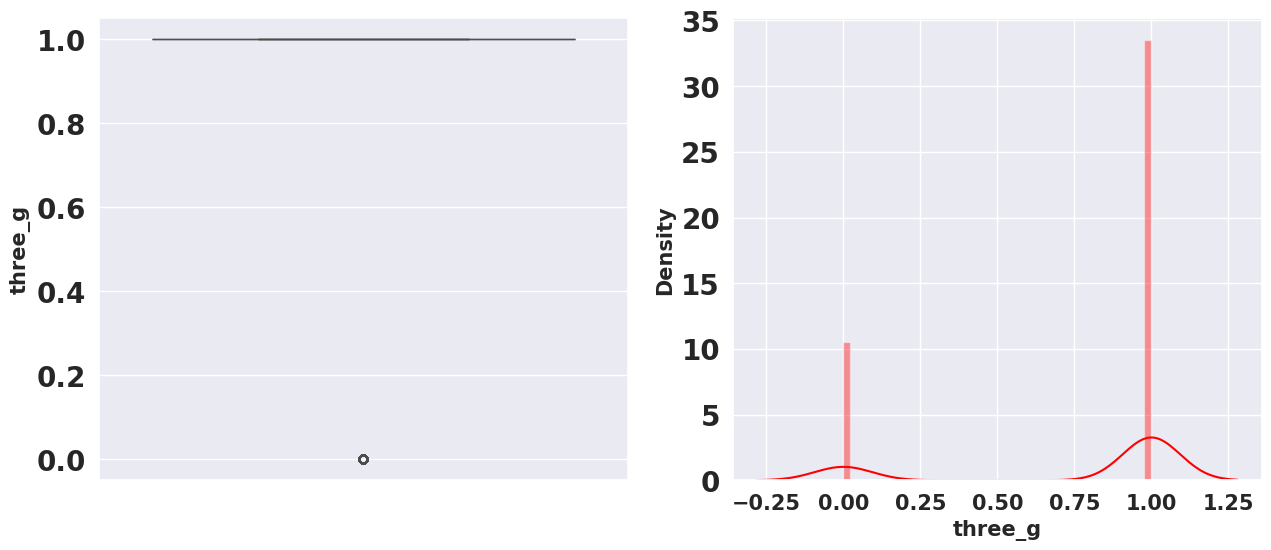

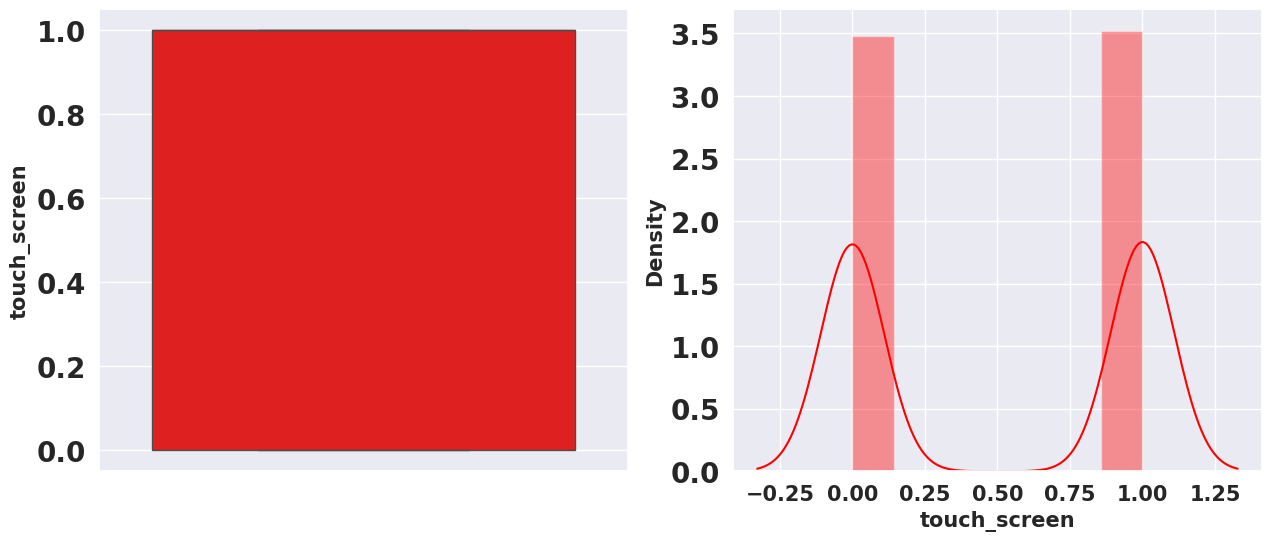

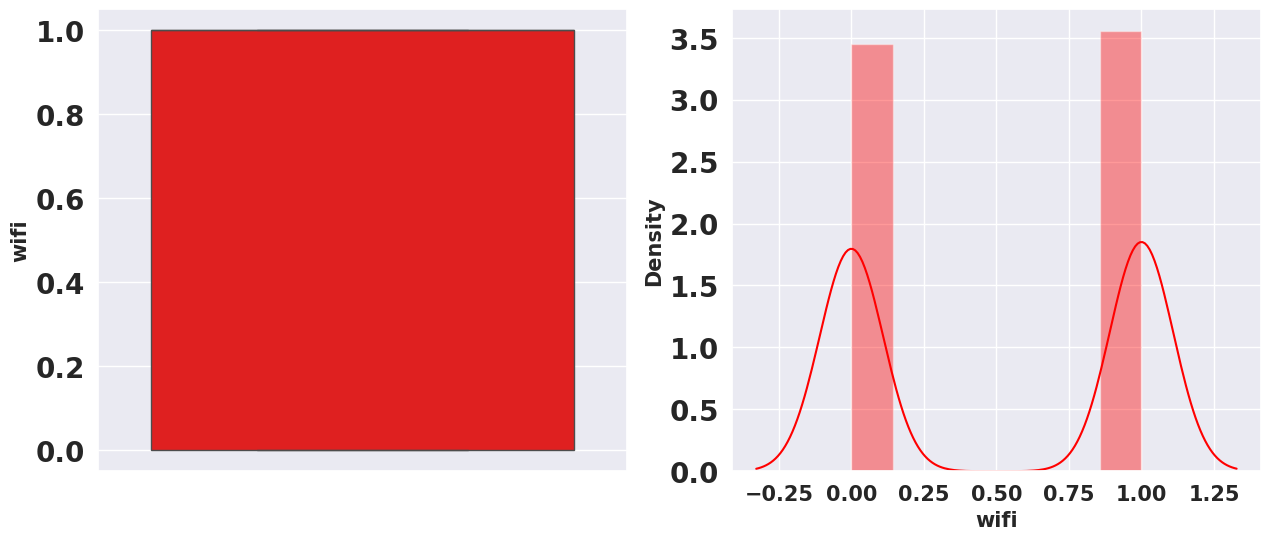

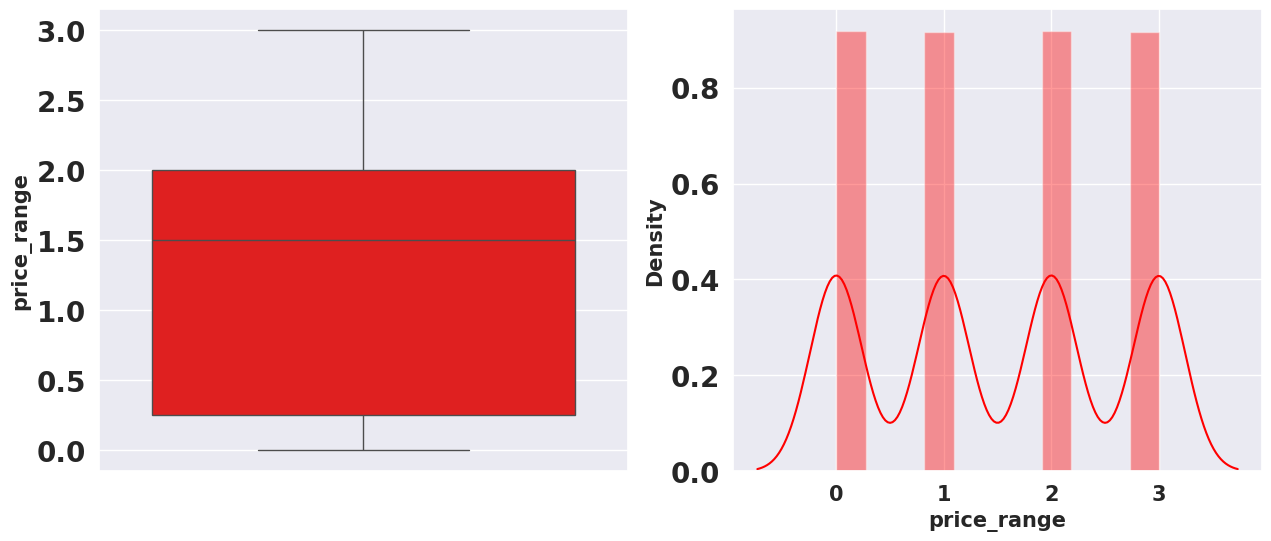

In [ ]:
# plotting boxplot and distribution
numeric_col = mobile_data.select_dtypes(include=np.number).columns.tolist()

for var in numeric_col:
    plt.figure(figsize=(15,6))
    plt.subplot(1,2,1)
    fig = sns.boxplot(y=mobile_data[var],color='red')
    fig.set_title('')
    fig.set_ylabel(var)

    plt.subplot(1,2,2)
    fig = sns.distplot(mobile_data[var],color='red')

    fig.set_xlabel(var)

    plt.show()

In [ ]:
mobile_data.shape

(1998, 21)

# **So we have handled Outliers.**

In [ ]:
# create copy of mobile_data
mobile_data_copy=mobile_data.copy()

# **Features Selection**

In [ ]:
# checking newly created column.
mobile_data.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842.0,0.0,2.2,0.0,1.0,0.0,7.0,0.6,188.0,2.0,2.0,20.0,756.0,2549.0,9.0,7.0,19.0,0.0,0.0,1.0,1.0
1,1021.0,1.0,0.5,1.0,0.0,1.0,53.0,0.7,136.0,3.0,6.0,905.0,1988.0,2631.0,17.0,3.0,7.0,1.0,1.0,0.0,2.0
2,563.0,1.0,0.5,1.0,2.0,1.0,41.0,0.9,145.0,5.0,6.0,1263.0,1716.0,2603.0,11.0,2.0,9.0,1.0,1.0,0.0,2.0
3,615.0,1.0,2.5,0.0,0.0,0.0,10.0,0.8,131.0,6.0,9.0,1216.0,1786.0,2769.0,16.0,8.0,11.0,1.0,0.0,0.0,2.0
4,1821.0,1.0,1.2,0.0,13.0,1.0,44.0,0.6,141.0,2.0,14.0,1208.0,1212.0,1411.0,8.0,2.0,15.0,1.0,1.0,0.0,1.0


In [ ]:
# # create new column screen size.
# mobile_data['screen_size']= round(np.sqrt(mobile_data['sc_h']**2+mobile_data['sc_w']**2)/2.54,2)

In [ ]:
# mobile_data['Pixels']=mobile_data['px_height']*mobile_data['px_width']

In [ ]:
# mobile_data.drop(columns=["sc_h",'sc_w','px_height','px_width'],axis=1,inplace=True)

<Axes: >

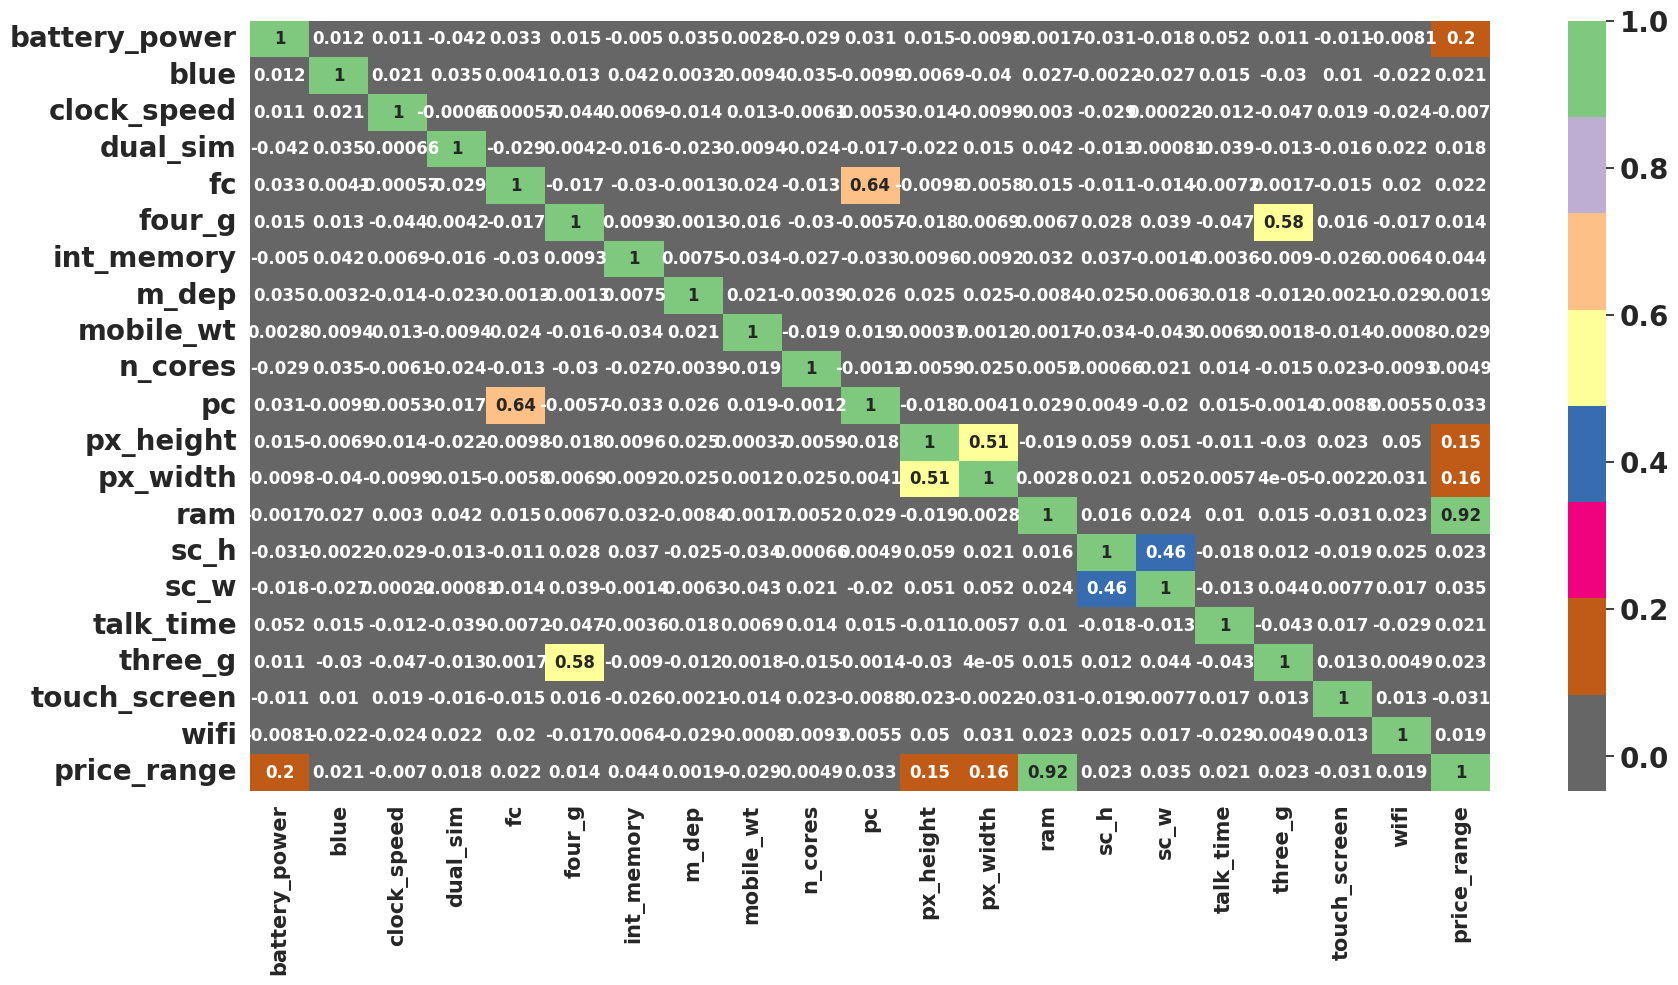

In [ ]:
corr= mobile_data.corr()
plt.figure(figsize=(20,10))
sns.heatmap(corr,annot=True,cmap=plt.cm.Accent_r)

In [ ]:
# separating X variables(independent variables) and Y(dependent variable) variable.
X=mobile_data.drop('price_range',axis=1)
Y=mobile_data['price_range']

In [ ]:
# from sklearn.feature_selection import mutual_info_classif
# # determine the mutual information
# mutual_info = mutual_info_classif(x,y)
# mutual_info

In [ ]:
# mutual_info = pf.Series(mutual_info)
# mutual_info.index = X.columns
# mutual_info.sort_values(ascending=False)

In [ ]:
# #let's plot the orderes mutual_info values per feature
# mutual_info.sort_values(acsending_False).plot.bar(figsize=(10,8))
# plt.ylabel('Mutual Information values')
# plt.xlabels('Features')
# plt.title('mutual_info values per feature')

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

In [ ]:
#No we will select the top 12 important features
best_features=SelectKBest(score_func=chi2,k=12)
fit=best_features.fit(X,Y)

In [ ]:
# creating score's and column's dataframe
df_scores=pd.DataFrame(fit.scores_)
df_columns=pd.DataFrame(X.columns)

In [ ]:
# concatenating above two dataframes
featureScores=pd.concat([df_columns,df_scores],axis=1)
featureScores.columns=['Specs','Score']

In [ ]:
# check dataframe
featureScores

,Specs,Score
0,battery_power,14006.667515
1,blue,0.782701
2,clock_speed,0.672292
3,dual_sim,0.674269
4,fc,10.151403
5,four_g,1.468373
6,int_memory,89.148626
7,m_dep,0.738846
8,mobile_wt,93.731705
9,n_cores,9.455162


In [ ]:
# 12 features with highest chi squared statistics
print(featureScores.nlargest(12,'Score'))

            Specs          Score
13            ram  930468.599482
11      px_height   17606.962872
0   battery_power   14006.667515
12       px_width    9685.341009
8       mobile_wt      93.731705
6      int_memory      89.148626
16      talk_time      13.433547
4              fc      10.151403
14           sc_h       9.505140
9         n_cores       9.455162
15           sc_w       9.426742
10             pc       9.141022


In [ ]:
# 12 features with highest chi squared statistics are selected as independent variables.
X=mobile_data[['ram','px_height','battery_power','px_width','mobile_wt','int_memory','sc_h','talk_time','sc_w','fc','n_cores','pc']]

# dependent variable
y=mobile_data['price_range']

# **Predictive Modeling:**

Predictive modeling is a process of using statistical and machine learning techniques to analyze data and build models that can be used to predict future outcomes or behavior. It involves identifying patterns and relationships in historical data and using this information to develop models that can be used to predict future events or behaviors with a high degree of accuracy. Algorithms used for predictive modeling:

1) Decision Tree

2) Random Forest classifier

3) Gradient Boosting Classifier

4) K-nearest Neighbour classifier

5) XG Boost Classifier

6) Support Vector Machine(SVM)

**As Decision tree,random forest and enssembles tress do not require Feature scalling as these are Tress based moidels.So we will be using X_train and X_test which are not scaled.**



**For K nearest Neighbors and SVM we will be using X_train_scaled and X_test_scaled. This is we will use Standardised data. i.e. Scaled data. As these are distance based Algorithms.**

In [ ]:
# importing all essential libraries.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay # Import ConfusionMatrixDisplay

In [ ]:
# splitting the data into Train and test data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1498, 12)
(500, 12)
(1498,)
(500,)


In [ ]:
# Scaling the data.
# creating an object of MinMax Scaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)  # fitting the X_train
X_test_scaled=scaler.transform(X_test)        # transforming X_test

In [ ]:
X_train_scaled

array([[-0.5569464 ,  2.17433843,  0.48153645, ..., -0.97448889,
         0.22343391, -1.11407372],
       [-0.4280024 , -0.01353806, -0.71269622, ..., -0.74303426,
         1.10889424, -0.78687395],
       [ 0.08128001,  0.0719083 , -0.05176593, ...,  0.18278427,
        -1.54748674,  1.50352445],
       ...,
       [-1.48552872, -0.63639705,  1.1310714 , ...,  1.34005742,
         0.66616408,  1.33992456],
       [-1.00685891, -1.07936896, -0.09051012, ..., -0.51157963,
        -1.54748674, -0.45967418],
       [ 0.28350873, -0.26088279, -1.19585906, ...,  2.03442132,
        -0.66202641,  1.50352445]])

In [ ]:
X_test_scaled

array([[ 1.2111634 , -0.91971918,  0.50888529, ..., -0.74303426,
        -0.21929625, -1.11407372],
       [ 1.62489738, -1.42790016, -1.6402777 , ..., -0.74303426,
        -1.10475658,  0.03112548],
       [-1.06159054, -1.07262319, -0.4483241 , ..., -0.51157963,
        -0.66202641, -0.95047383],
       ...,
       [ 0.0979778 ,  1.51999921,  0.16474572, ...,  0.4142389 ,
         1.55162441,  0.84912491],
       [ 0.31597664, -0.86575306,  0.0143271 , ..., -0.51157963,
         1.55162441, -0.78687395],
       [-0.92800827, -0.5284648 , -0.54176597, ..., -0.97448889,
         1.10889424,  0.52192514]])

In [ ]:
# Deffining a function for plotting roc curve
def plot_Aur_roc(y_test,pred_):
  '''It will take y_test and y predicted probabilities
  as input and will plot the roc curve.'''

  fpr = {}
  tpr = {}
  thresh ={}

  n_calss = 4

  for i in range(n_calss):
    fpr[i], tpr[i], thresh[i] = roc_curve(y_test, pred_[:,i], pos_label=i)

  # plotting
  plt.figure(figsize=(12,8))
  plt.plot(fpr[0], tpr[0], linestyle='--',color='orange', label=((f'Class 0(low cost) vs Rest, AUC={round(auc(fpr[0], tpr[0]),4)}')))
  plt.plot(fpr[1], tpr[1], linestyle='--',color='green', label=((f'Class 1(medium cost) vs Rest, AUC={round(auc(fpr[1], tpr[1]),2)}')))
  plt.plot(fpr[2], tpr[2], linestyle='--',color='blue', label=((f'Class 2(high cost) vs Rest, AUC={round(auc(fpr[2], tpr[2]),2)}')))
  plt.plot(fpr[3], tpr[3], linestyle='--',color='yellow', label=((f'Class 3(very high cost) vs Rest, AUC={round(auc(fpr[3], tpr[3]),2)}')))
  plt.title('Multiclass ROC curve')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive rate')
  plt.legend(loc='best')
  plt.savefig('Multiclass ROC',dpi=300);

In [ ]:
# creating a class list
class_list=['low cost','medium cost','high cost','very high cost']

# **1)Decision Tree Classifier:**

**Decision tress and ensemble methods do not require features scaling to be performed as they are not sensitive to the variance in the data. So here we will use X_train,X_test,y_test and y_train which are not scaled.**

**Decision Tree with default hyperparameters:**

In [ ]:
# creating object of the decision three.
dtc=DecisionTreeClassifier(random_state=0)

In [ ]:
# fitting/tarining the train set.
dtc.fit(X_train,y_train)

DecisionTreeClassifier(random_state=0)

In [ ]:
# predicting y values of train and test data.
y_pred_train=dtc.predict(X_train)
y_pred_test=dtc.predict(X_test)

In [ ]:
# checking train set accuracy.
accuracy_score(y_train,y_pred_train)

1.0

In [ ]:
# checking test set accuracy
accuracy_score(y_test,y_pred_test)

0.846

In [ ]:
# Confusion matrix for test set.
cf_matrix=confusion_matrix(y_test,y_pred_test)
cf_matrix

array([[118,  10,   0,   0],
       [  7,  91,  10,   0],
       [  0,  15, 102,  16],
       [  0,   0,  19, 112]])

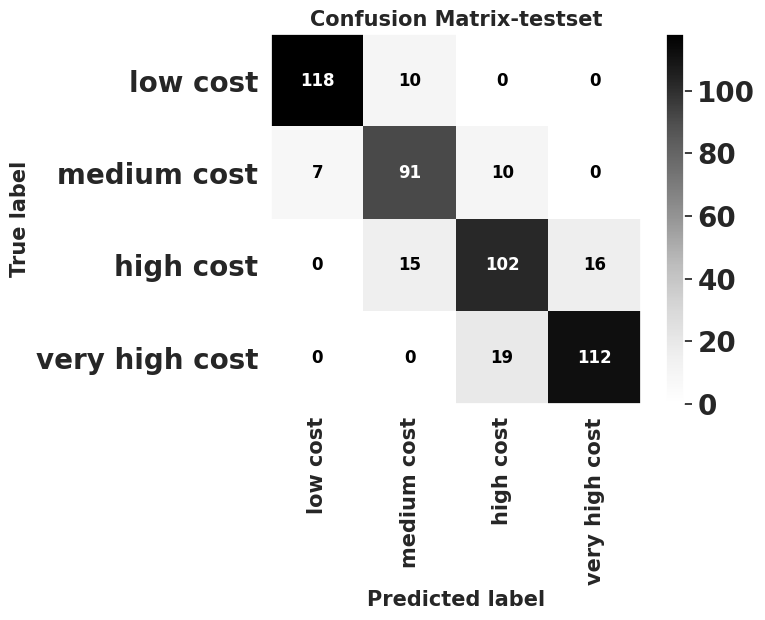

In [ ]:
# plotting confusion matrix for tst set.
ConfusionMatrixDisplay.from_estimator(dtc,X_test,y_test,cmap='Greys',display_labels=class_list,xticks_rotation='vertical')
plt.grid(False)
plt.title('Confusion Matrix-testset',fontsize=15)
plt.show()

In [ ]:
# Printing classification of train set.
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       372
         1.0       1.00      1.00      1.00       391
         2.0       1.00      1.00      1.00       367
         3.0       1.00      1.00      1.00       368

    accuracy                           1.00      1498
   macro avg       1.00      1.00      1.00      1498
weighted avg       1.00      1.00      1.00      1498





*   Train set accuracy is 100% and test accuracy is 84%.

*   Model is overfitted on train set and did not generalised well.
*  We will tune hyperparameters to reduce overfitting and try to improve the model performance.

# **Let's tune some hyperparameters pf Decision Tree classifier:**

In [ ]:
# creating an object of classifier.
dtc=DecisionTreeClassifier(random_state=0)

In [ ]:
from enum import auto
# parameter grid values for hyperparameter tunning.
grid_values={'criterion':['gini','entropy'],
             'max_depth':[2,3,4,5,6,9,10,11,12,13,14,15],
             'splitter':['best','random'],
             'min_samples_split':[3,5,10],
             'max_features':['auto','sqrt','log2',None]}

In [ ]:
# applying GridSearchCv and fitting the model with it.
dtc_tune=GridSearchCV(dtc,param_grid=grid_values,cv=5,scoring='accuracy',verbose=3)
dtc_tune.fit(X_train,y_train)   # model fitting

Fitting 5 folds for each of 576 candidates, totalling 2880 fits
[CV 1/5] END criterion=gini, max_depth=2, max_features=auto, min_samples_split=3, splitter=best;, score=nan total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=2, max_features=auto, min_samples_split=3, splitter=best;, score=nan total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=2, max_features=auto, min_samples_split=3, splitter=best;, score=nan total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=2, max_features=auto, min_samples_split=3, splitter=best;, score=nan total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=2, max_features=auto, min_samples_split=3, splitter=best;, score=nan total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=2, max_features=auto, min_samples_split=3, splitter=random;, score=nan total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=2, max_features=auto, min_samples_split=3, splitter=random;, score=nan total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=2, m

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 14,
                                       15],
                         'max_features': ['auto', 'sqrt', 'log2', None],
                         'min_samples_split': [3, 5, 10],
                         'splitter': ['best', 'random']},
             scoring='accuracy', verbose=3)

In [ ]:
# getting best parameters for model.
dtc_tune.best_params_

{'criterion': 'entropy',
 'max_depth': 10,
 'max_features': None,
 'min_samples_split': 10,
 'splitter': 'best'}

In [ ]:
# getting best estimators
dtc_tune.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_split=10,
                       random_state=0)

In [ ]:
# using best parameters and tarining the data.
dtc_optimal=DecisionTreeClassifier(criterion='entropy',max_depth=9,min_samples_split=10,
                        random_state=0)
dtc_optimal.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=9, min_samples_split=10,
                       random_state=0)

In [ ]:
# predicting y values of thrain and test set.
y_pred_train=dtc_optimal.predict(X_train)
y_pred_test=dtc_optimal.predict(X_test)

In [ ]:
# checking the accuracy score of test set.
accuracy_score(y_test,y_pred_test)

0.856

In [ ]:
# checking the accuracy score of train set.
accuracy_score(y_train,y_pred_train)

0.9572763684913218

In [ ]:
# getting confusion matrix for test set.
cf_matrix=confusion_matrix(y_test,y_pred_test)
cf_matrix

array([[113,  15,   0,   0],
       [  6,  98,   4,   0],
       [  0,  11, 110,  12],
       [  0,   0,  24, 107]])

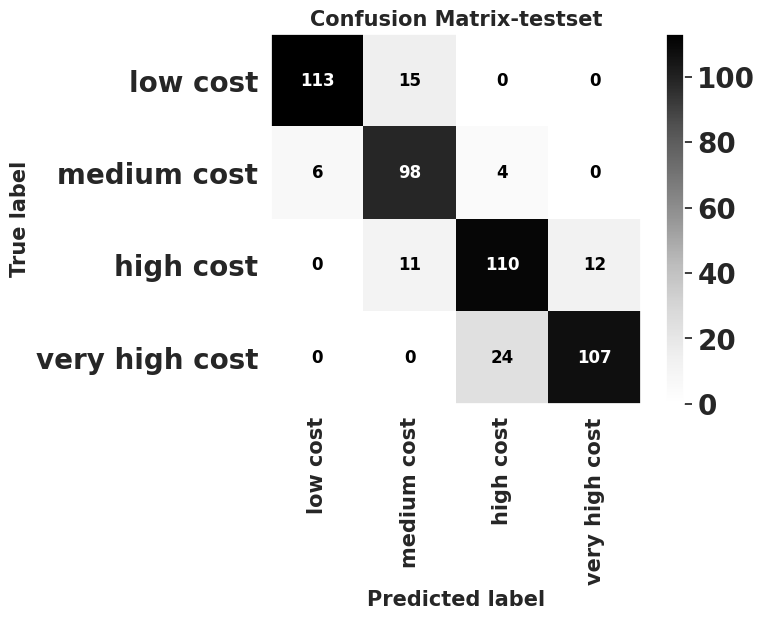

In [ ]:
# plotting confusion matrix for test set.
ConfusionMatrixDisplay.from_estimator(dtc_optimal,X_test,y_test,cmap='Greys',display_labels=class_list,xticks_rotation='vertical')
plt.grid(False)
plt.title('Confusion Matrix-testset',fontsize=15)
plt.show()

In [ ]:
# printing classification report for train set.
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

         0.0       0.98      0.97      0.98       372
         1.0       0.92      0.97      0.95       391
         2.0       0.95      0.92      0.93       367
         3.0       0.98      0.97      0.97       368

    accuracy                           0.96      1498
   macro avg       0.96      0.96      0.96      1498
weighted avg       0.96      0.96      0.96      1498



In [ ]:
# printing classification report for test set.
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

         0.0       0.95      0.88      0.91       128
         1.0       0.79      0.91      0.84       108
         2.0       0.80      0.83      0.81       133
         3.0       0.90      0.82      0.86       131

    accuracy                           0.86       500
   macro avg       0.86      0.86      0.86       500
weighted avg       0.86      0.86      0.86       500



In [ ]:
# creating a function for plotting the feature importances.
def plot_feature_importance(algo):
  '''Takes the alogrithm as input and
  plots the feature importance graph'''

  # get importance
  importance = algo.feature_importances_
  feat_importance=pd.DataFrame({'Features':X.columns,'score':importance}).sort_values(by='score',ascending=False)
  plt.figure(figsize=(10,8))
  sns.barplot(x=feat_importance['score'],y=feat_importance['Features'])
  plt.title('Feature Importance')

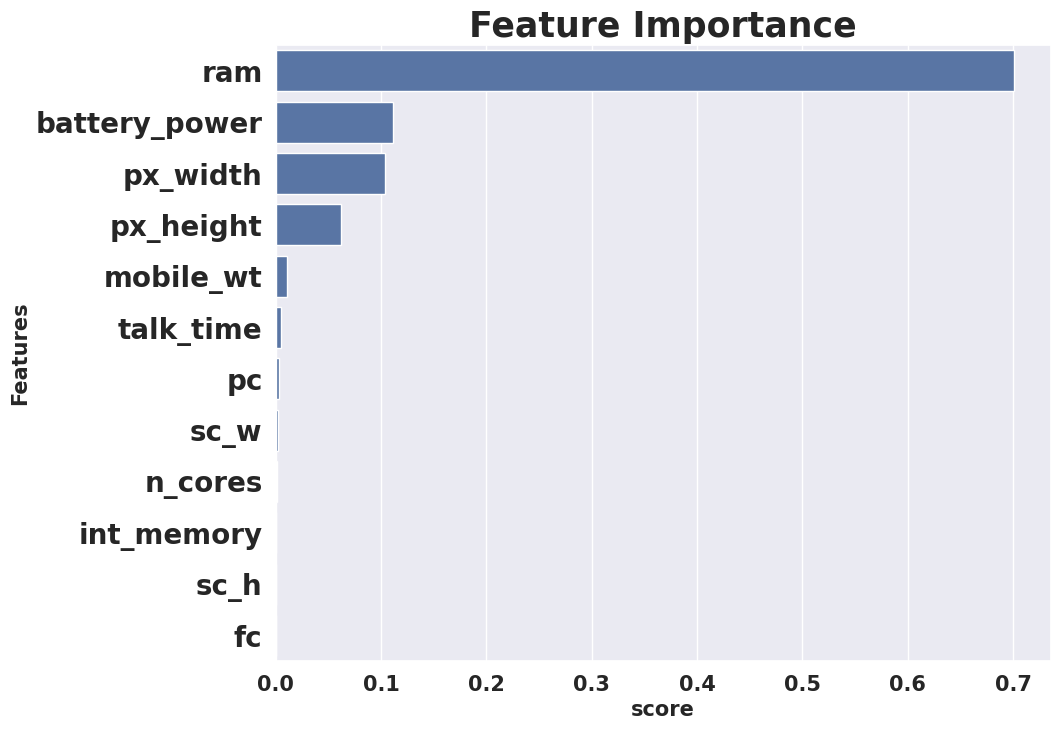

In [ ]:
#plotting feature importances
plot_feature_importance(dtc_optimal)

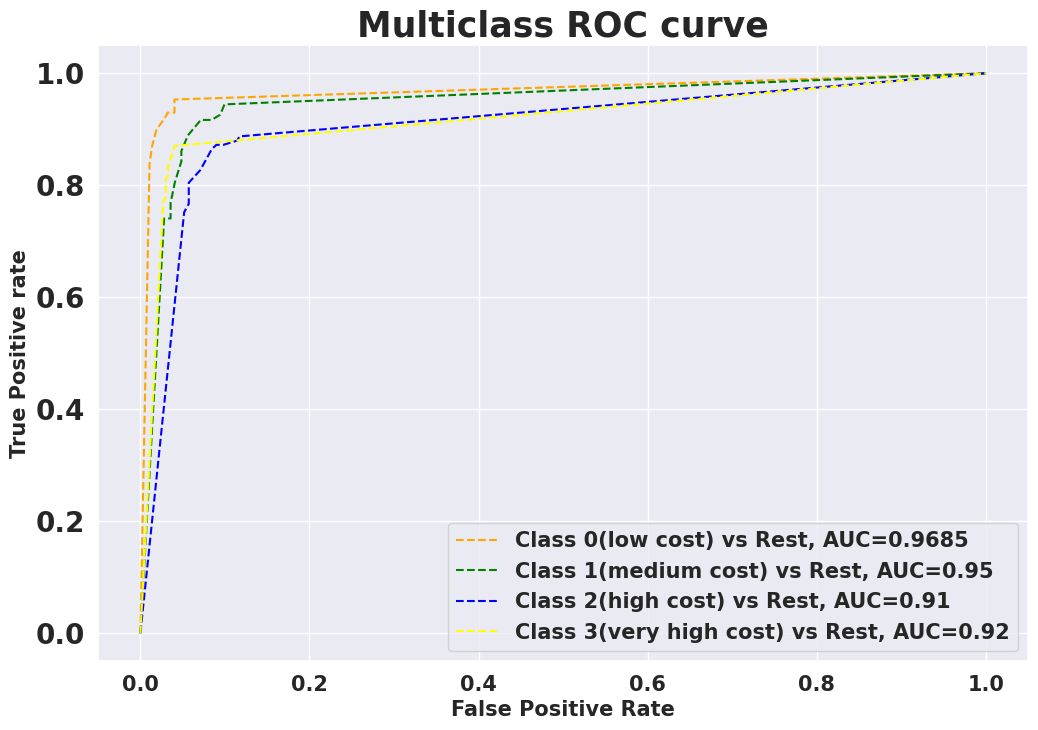

In [ ]:
# plot AUC ROC curve.
pred_prob=dtc_optimal.predict_proba(X_test)
plot_Aur_roc(y_test,pred_prob)

# **Decision Tree Classifier-Observations:**


*   Train accuarcy has been reduced to 98% from 100% and test accuarcy is increased by 1%. Thus we somewhat reduced the overfiiting by reducing the training accuarcy. However this will not be good model for us.

*   RAM, battery power,px_height and width came out to be the most important features
*  This model classified the class 0 and class 3 very nicely as we can see the AUC is almost 0.96 for both classes, whereas for class 1 and class 2 it is 0.88.

# **2)Random Forest Classifier:**

### **With default hyperparameters:**

In [ ]:
# splitting the data into trainset and test set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [ ]:
# creating an object of the classifier.
rfc=RandomForestClassifier(random_state=0)

In [ ]:
# fitting/training the model.
rfc.fit(X_train,y_train)

RandomForestClassifier(random_state=0)

In [ ]:
# predicting the y values of train set and test set.
y_pred_train=rfc.predict(X_train)
y_pred_test=rfc.predict(X_test)

In [ ]:
# checking the accuracy score of train set.
accuracy_score(y_train,y_pred_train)

1.0

In [ ]:
# checking the accuracy score of train set.
accuracy_score(y_test,y_pred_test)

0.89

In [ ]:
# confusion matrix forvtest set.
cf_matrix=confusion_matrix(y_test,y_pred_test)
cf_matrix

array([[124,   4,   0,   0],
       [  6,  93,   9,   0],
       [  0,  17, 108,   8],
       [  0,   0,  11, 120]])

## **Let's some Hyperparameter Tunning of the Random forest model**

In [ ]:
# para_grid values to pass in gridsearchcv.
grid_values={'n_estimators':[300,400,500,700],
             'max_depth':[None,10,20,40],
             'min_samples_split':[2,6,10],
             'max_leaf_nodes':[None],
             'criterion':['gini','entropy'],
             'max_features':['auto','log2','sqrt']
             }

In [ ]:
# creating the instance
rfc=RandomForestClassifier(random_state=0)


# **Observations of Random Forest:**

**Before Tuning**


*   training accuarcy = 100%

* test accuarcy = 88%  

Model is overfitted the data and does not generalised well. So we tuned the hyperparameters.

**After tuning:**


* Training accuarcy= 100%
*   Test accuarcy = 90%

we have slightly improved the model and overfitting is reduced slightly.

From roc curve its clear that model has poorly performed to classify class 1 and class 2.

# **3)Gradient Boosting Classifier:**

## **With default hyperparameters:**

In [ ]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [ ]:
# creating an object of the classifier
gbc=GradientBoostingClassifier(random_state=0)

In [ ]:
# fitting/training the data
gbc.fit(X_train,y_train)

GradientBoostingClassifier(random_state=0)

In [ ]:
# predicting y values of train and test set.
y_pred_train=gbc.predict(X_train)
y_pred_test=gbc.predict(X_test)

In [ ]:
# checking the accuracy score of train data
accuracy_score(y_train,y_pred_train)

1.0

In [ ]:
# checking the accuracy score of the test data
accuracy_score(y_test,y_pred_test)

0.91

Text(0.5, 1.0, 'Confusion Matrix-testset')

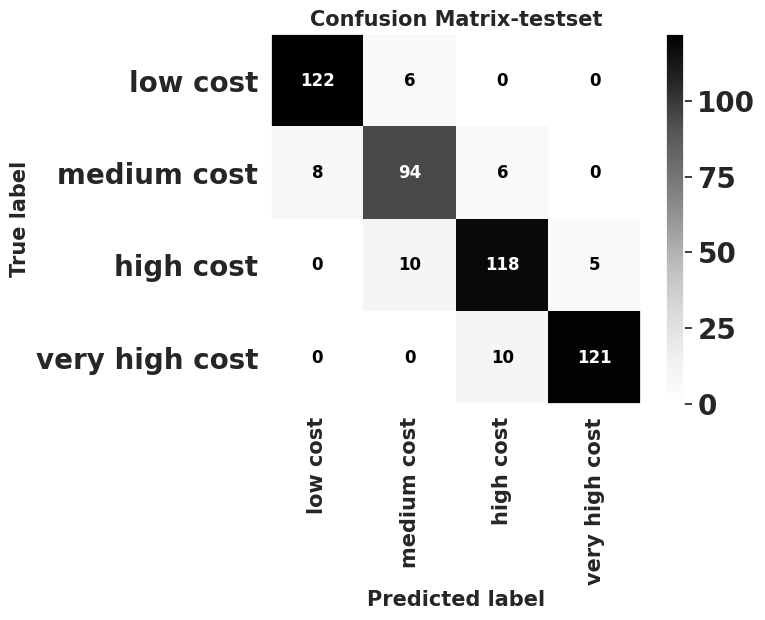

In [ ]:
# plotting confusion matrix for test set
ConfusionMatrixDisplay.from_estimator(gbc,X_test,y_test,cmap='Greys',display_labels=class_list,xticks_rotation='vertical')
plt.grid(False)
plt.title('Confusion Matrix-testset',fontsize=15)

In [ ]:
# confusion matrix
cf_matrix=confusion_matrix(y_test,y_pred_test)
cf_matrix

array([[122,   6,   0,   0],
       [  8,  94,   6,   0],
       [  0,  10, 118,   5],
       [  0,   0,  10, 121]])

## **Let's do some hyperparameter tunning.**

In [ ]:
# creating an object of the classifier
gbc=GradientBoostingClassifier(random_state=0)

In [ ]:
# para_grid values to pass in gridsearchcv
grid_values={'learning_rate':[0.005,1,2,3],
             'min_samples_split':range(10,26)

}

In [ ]:
# applying GridSearchcv
gbc_tune=GridSearchCV(gbc,param_grid=grid_values,cv=3,verbose=1,scoring='accuracy')
gbc_tune.fit(X_train,y_train)

Fitting 3 folds for each of 64 candidates, totalling 192 fits


GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=0),
             param_grid={'learning_rate': [0.005, 1, 2, 3],
                         'min_samples_split': range(10, 26)},
             scoring='accuracy', verbose=1)

In [ ]:
# Getting best parameters
gbc_tune.best_params_

{'learning_rate': 1, 'min_samples_split': 22}

In [ ]:
# getting best estimators
gbc_tune.best_estimator_

GradientBoostingClassifier(learning_rate=1, min_samples_split=22,
                           random_state=0)

In [ ]:
# applying best estimators
gbc_optimal=GradientBoostingClassifier(learning_rate=1,min_samples_split=25,random_state=0)
gbc_optimal.fit(X_train,y_train)

GradientBoostingClassifier(learning_rate=1, min_samples_split=25,
                           random_state=0)

In [ ]:
# predicting the y values of train and test set.
y_pred_train=gbc_optimal.predict(X_train)
y_pred_test=gbc_optimal.predict(X_test)

In [ ]:
# train set accuracy score
accuracy_score(y_train,y_pred_train)

0.9993324432576769

In [ ]:
# test set accuracy score
accuracy_score(y_test,y_pred_test)

0.908

In [ ]:
# confusion matrix
cf_matrix=confusion_matrix(y_test,y_pred_test)
cf_matrix

array([[121,   7,   0,   0],
       [  6,  95,   7,   0],
       [  0,  11, 115,   7],
       [  0,   0,   8, 123]])

In [ ]:
# printing the classification report of the train set.
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       372
         1.0       1.00      1.00      1.00       391
         2.0       1.00      1.00      1.00       367
         3.0       1.00      1.00      1.00       368

    accuracy                           1.00      1498
   macro avg       1.00      1.00      1.00      1498
weighted avg       1.00      1.00      1.00      1498



In [ ]:
# printing the classification report of test set.
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

         0.0       0.95      0.95      0.95       128
         1.0       0.84      0.88      0.86       108
         2.0       0.88      0.86      0.87       133
         3.0       0.95      0.94      0.94       131

    accuracy                           0.91       500
   macro avg       0.91      0.91      0.91       500
weighted avg       0.91      0.91      0.91       500



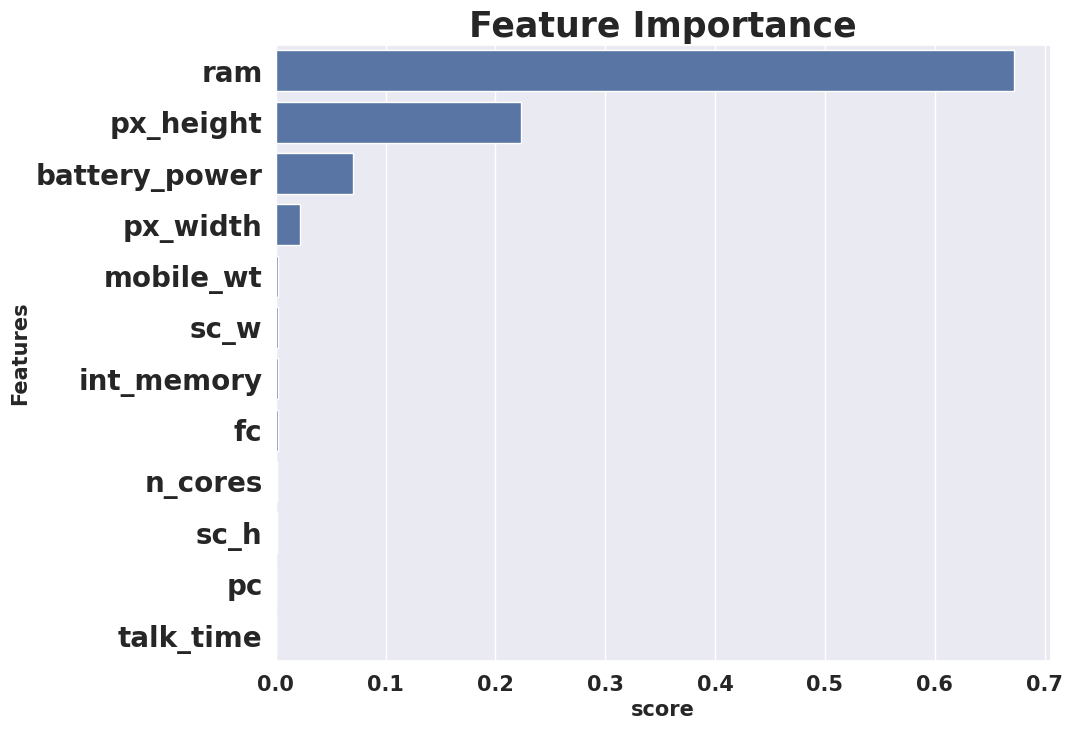

In [ ]:
# plotting feature importances
plot_feature_importance(gbc_optimal)

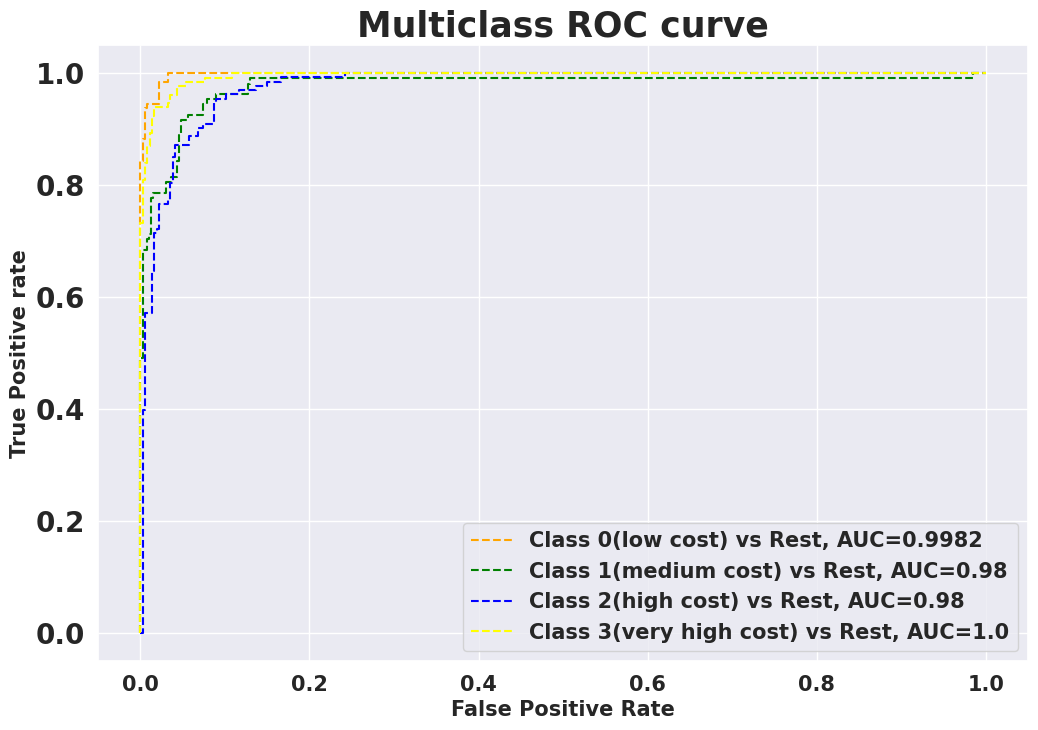

In [ ]:
# plot AUR ROC curve.
pred_prob=gbc_optimal.predict_proba(X_test)
plot_Aur_roc(y_test,pred_prob)

# **Observations of Gradient Boost Classifiers:**

**Before tunning:**  

*   Train accuracy score= 100%.
*   Test accuracy score= 89%

Model did not generalised well and overfitted the training data. so we tuned hyperparameters of model.

**After Hyperparameter Tuning**



*   Train accuracy score= 100%
*   Test accuarcy score=90%

Thus we slightly improved the model performance. However the model is not best.

From ROC curve it's clear that model was good to classify the class 0 and class 3. From the classification report its clear that recall for class 0 and class 3 is also good which is 96% and 90% respectively.

# **4)K Nearest Neighbors:**



**With default hyperparameters:**

In [ ]:
knn=KNeighborsClassifier()     # creating an object of the classifier
knn.fit(X_train_scaled,y_train)   # fitting the data

KNeighborsClassifier()

In [ ]:
#predicting the y values of train and test set.
y_pred_train=knn.predict(X_train_scaled)
y_pred_test=knn.predict(X_test_scaled)

In [ ]:
# checking the accuracy score of test set.
accuracy_score(y_test,y_pred_test)

0.618

In [ ]:
# confusion matrix
cf_matrix=confusion_matrix(y_test,y_pred_test)
cf_matrix

array([[98, 28,  2,  0],
       [30, 57, 21,  0],
       [ 2, 55, 69,  7],
       [ 0,  8, 38, 85]])

In [ ]:
# printing the classification report of test set.
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

         0.0       0.75      0.77      0.76       128
         1.0       0.39      0.53      0.45       108
         2.0       0.53      0.52      0.52       133
         3.0       0.92      0.65      0.76       131

    accuracy                           0.62       500
   macro avg       0.65      0.62      0.62       500
weighted avg       0.66      0.62      0.63       500



# **Let's do some HyperParameter tuning.**

In [ ]:
# creating an object of classifier
knn=KNeighborsClassifier()

In [ ]:
# parameter grid values.
grid_values={'n_neighbors':list(range(1, 31))}

In [ ]:
# applying GridSearchCv with above grid values and cv=5
knn_tune=GridSearchCV(knn,cv=5,scoring='accuracy',verbose=3,param_grid=grid_values)
knn_tune.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END .....................n_neighbors=1;, score=0.600 total time=   0.0s
[CV 2/5] END .....................n_neighbors=1;, score=0.540 total time=   0.0s
[CV 3/5] END .....................n_neighbors=1;, score=0.570 total time=   0.0s
[CV 4/5] END .....................n_neighbors=1;, score=0.548 total time=   0.0s
[CV 5/5] END .....................n_neighbors=1;, score=0.555 total time=   0.0s
[CV 1/5] END .....................n_neighbors=2;, score=0.567 total time=   0.0s
[CV 2/5] END .....................n_neighbors=2;, score=0.560 total time=   0.0s
[CV 3/5] END .....................n_neighbors=2;, score=0.503 total time=   0.0s
[CV 4/5] END .....................n_neighbors=2;, score=0.512 total time=   0.0s
[CV 5/5] END .....................n_neighbors=2;, score=0.559 total time=   0.0s
[CV 1/5] END .....................n_neighbors=3;, score=0.600 total time=   0.0s
[CV 2/5] END .....................n_neighbors=3

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24, 25, 26, 27, 28, 29, 30]},
             scoring='accuracy', verbose=3)

In [ ]:
# Getting best parameters
knn_tune.best_params_

{'n_neighbors': 30}

In [ ]:
# getting best estimators
knn_tune.best_estimator_

KNeighborsClassifier(n_neighbors=30)

In [ ]:
# applying best estimators
knn_optimal=KNeighborsClassifier(n_neighbors=1)
knn_optimal.fit(X_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=1)

In [ ]:
# predicting the y values of train and test set.
y_pred_train=knn_optimal.predict(X_train_scaled)
y_pred_test=knn_optimal.predict(X_test_scaled)

In [ ]:
# train set accuracy score
accuracy_score(y_train,y_pred_train)

1.0

In [ ]:
# confusion matrix
cf_matrix=confusion_matrix(y_test,y_pred_test)
cf_matrix

array([[88, 35,  5,  0],
       [26, 54, 27,  1],
       [ 5, 44, 66, 18],
       [ 0,  2, 40, 89]])

In [ ]:
# printing the classification report of the train set.
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       372
         1.0       1.00      1.00      1.00       391
         2.0       1.00      1.00      1.00       367
         3.0       1.00      1.00      1.00       368

    accuracy                           1.00      1498
   macro avg       1.00      1.00      1.00      1498
weighted avg       1.00      1.00      1.00      1498



In [ ]:
# printing the classification report of test set.
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

         0.0       0.74      0.69      0.71       128
         1.0       0.40      0.50      0.44       108
         2.0       0.48      0.50      0.49       133
         3.0       0.82      0.68      0.74       131

    accuracy                           0.59       500
   macro avg       0.61      0.59      0.60       500
weighted avg       0.62      0.59      0.60       500



# **Observations:**

**Before hyperparameters tuning:**

*   Train Accuracy:75%
*   Test Accuarcy:59%







Clearly Model has performed very worst. We did hyperparameter tuning

**After Hyperparameter Tuning:**

*   Train Accuarcy: 77%
*   Test Accuarcy: 70%

Surely we improved the model perfromance and reduced overfitting but however this is not good model for us.

# **5)XGBoost Classifier:**

**With default hyperparameter:**

In [ ]:
# splitting the data into train test split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [ ]:
xgb=XGBClassifier()       # creating an object of the classifier
xgb.fit(X_train,y_train)  # fitting the data

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# predicting y values of train and test data.
y_pred_train=xgb.predict(X_train)
y_pred_test=xgb.predict(X_test)

In [ ]:
# checking the accuracy score of test set.
accuracy_score(y_test,y_pred_test)

0.918

In [ ]:
# confusion matrix
cf_matrix=confusion_matrix(y_test,y_pred_test)
cf_matrix

array([[122,   6,   0,   0],
       [  4,  98,   6,   0],
       [  0,   7, 116,  10],
       [  0,   0,   8, 123]])

In [ ]:
# printing the classification report of test set.
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

         0.0       0.97      0.95      0.96       128
         1.0       0.88      0.91      0.89       108
         2.0       0.89      0.87      0.88       133
         3.0       0.92      0.94      0.93       131

    accuracy                           0.92       500
   macro avg       0.92      0.92      0.92       500
weighted avg       0.92      0.92      0.92       500



# **Let's do some HyperParameter tuning.**

In [ ]:
# parameter grid values for GridSearchCv
grid_values={
          'learning_rate':[0.6,1],
          'n_estimators':[500,1000],
          'gamma':[0.2],
          'subsample':[0.5,0.6]
         }

In [ ]:
# creating an object of the classifier
xgb=XGBClassifier()

# applying gridsearchcv
xgb_tune=GridSearchCV(xgb,grid_values, cv=3, verbose=4)
xgb_tune.fit(X_train,y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV 1/3] END gamma=0.2, learning_rate=0.6, n_estimators=500, subsample=0.5;, score=0.876 total time=   0.7s
[CV 2/3] END gamma=0.2, learning_rate=0.6, n_estimators=500, subsample=0.5;, score=0.882 total time=   0.3s
[CV 3/3] END gamma=0.2, learning_rate=0.6, n_estimators=500, subsample=0.5;, score=0.918 total time=   0.3s
[CV 1/3] END gamma=0.2, learning_rate=0.6, n_estimators=500, subsample=0.6;, score=0.886 total time=   0.2s
[CV 2/3] END gamma=0.2, learning_rate=0.6, n_estimators=500, subsample=0.6;, score=0.904 total time=   0.3s
[CV 3/3] END gamma=0.2, learning_rate=0.6, n_estimators=500, subsample=0.6;, score=0.930 total time=   0.3s
[CV 1/3] END gamma=0.2, learning_rate=0.6, n_estimators=1000, subsample=0.5;, score=0.884 total time=   0.5s
[CV 2/3] END gamma=0.2, learning_rate=0.6, n_estimators=1000, subsample=0.5;, score=0.884 total time=   0.5s
[CV 3/3] END gamma=0.2, learning_rate=0.6, n_estimators=1000, subsample=0.

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'gamma': [0.2], 'learning_rate': [0.6, 1],
                         'n_estimators': [500, 1000], 'subsample': [0.5, 0.6]},
             verbose=4)

In [ ]:
# Getting best parameters
xgb_tune.best_params_

{'gamma': 0.2, 'learning_rate': 0.6, 'n_estimators': 500, 'subsample': 0.6}

In [ ]:
# getting best estimators
xgb_tune.best_estimator_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.2, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.6, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# applying best estimators
xgb_optimal=XGBClassifier(gamma=0.2,learning_rate=1,n_estimators=1000,subsample=0.5)
xgb_optimal.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.2, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# predicting the y values of train and test set.
y_pred_train=xgb_optimal.predict(X_train)
y_pred_test=xgb_optimal.predict(X_test)

In [ ]:
# train set accuracy score
accuracy_score(y_train,y_pred_train)

1.0

In [ ]:
# confusion matrix
cf_matrix=confusion_matrix(y_test,y_pred_test)
cf_matrix

array([[122,   6,   0,   0],
       [  3, 101,   4,   0],
       [  0,  12, 117,   4],
       [  0,   0,  11, 120]])

In [ ]:
# printing the classification report of the train set.
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       372
         1.0       1.00      1.00      1.00       391
         2.0       1.00      1.00      1.00       367
         3.0       1.00      1.00      1.00       368

    accuracy                           1.00      1498
   macro avg       1.00      1.00      1.00      1498
weighted avg       1.00      1.00      1.00      1498



In [ ]:
# printing the classification report of test set.
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

         0.0       0.98      0.95      0.96       128
         1.0       0.85      0.94      0.89       108
         2.0       0.89      0.88      0.88       133
         3.0       0.97      0.92      0.94       131

    accuracy                           0.92       500
   macro avg       0.92      0.92      0.92       500
weighted avg       0.92      0.92      0.92       500



# **Observations**

**Before hyperparameter Tuning**

*   Train Accuarcy = 98%
*   Test Accuarcy = 90%

**After hyperparameter Tuning**

*  Train Accuarcy = 1%
*  Test Accuarcy = 92%

we have improved the model performance by Hyperparamter tuning. Test accuracy is increased to 92%. But still the difference of accuracy score

between train and test is more than 5%. We can say model is very slightly overfitted

From AUC-ROC curve its clear that model has almost correctly predicted the class 0 and class 3.

# **6)SVM**

**With default hyperparameters**

In [ ]:
# Import all relevant libraries

from sklearn.svm import SVC

In [ ]:
svc = SVC(random_state=101)    # creating an object of classifier
svc.fit(X_train,y_train)       # fitting the model/training the model.

SVC(random_state=101)

In [ ]:
# predicting the y value of train set and test set
y_pred_train=svc.predict(X_train_scaled)
y_pred_test=svc.predict(X_test_scaled)

In [ ]:
# accuracy score for train set
accuracy_score(y_train,y_pred_train)

0.24833110814419226

In [ ]:
# accuracy score for test set
accuracy_score(y_test,y_pred_test)

0.256

In [ ]:
cf_matrix=confusion_matrix(y_test,y_pred_test)
cf_matrix

array([[128,   0,   0,   0],
       [108,   0,   0,   0],
       [133,   0,   0,   0],
       [131,   0,   0,   0]])

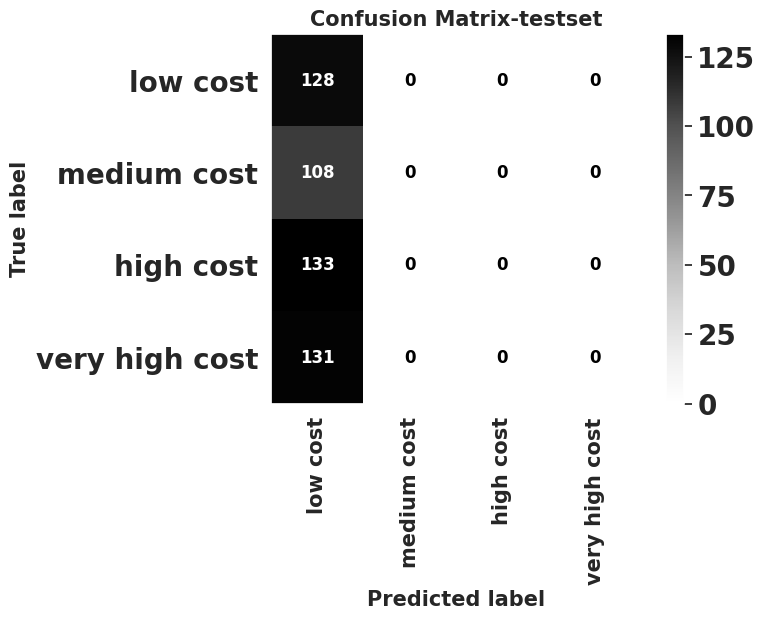

In [ ]:
# plotting confusion matrix for test set.
ConfusionMatrixDisplay.from_estimator(svc,X_test_scaled,y_test,cmap='Greys',display_labels=class_list,xticks_rotation='vertical')
plt.grid(False)
plt.title('Confusion Matrix-testset',fontsize=15)
plt.show()

In [ ]:
#printing the classification report of train set.
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

         0.0       0.25      1.00      0.40       372
         1.0       0.00      0.00      0.00       391
         2.0       0.00      0.00      0.00       367
         3.0       0.00      0.00      0.00       368

    accuracy                           0.25      1498
   macro avg       0.06      0.25      0.10      1498
weighted avg       0.06      0.25      0.10      1498



In [ ]:
#printing the classification report of train set.
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

         0.0       0.26      1.00      0.41       128
         1.0       0.00      0.00      0.00       108
         2.0       0.00      0.00      0.00       133
         3.0       0.00      0.00      0.00       131

    accuracy                           0.26       500
   macro avg       0.06      0.25      0.10       500
weighted avg       0.07      0.26      0.10       500



**Hyperparameter Tuning**

In [ ]:
# parameter grid for GridSearchCv
grid_values = {
    'C': [0.01, 0.1, 1, 10],
    'kernel' : ["linear", "rbf", "poly","sigmoid"],
    'degree' : [1,3,5,7],
    'gamma' : [0.01,1]
}

In [ ]:
# creating an object for classifier
scm = SVC ()

In [ ]:
# Hyperparameter tuning with the GrdiSearchCV with cv=5
svm_cv = GridSearchCV(scm, grid_values, cv=5, verbose=2)
svm_cv.fit(X_train_scaled, y_train)       # fitting the data into the model

Fitting 5 folds for each of 128 candidates, totalling 640 fits
[CV] END ........C=0.01, degree=1, gamma=0.01, kernel=linear; total time=   0.3s
[CV] END ........C=0.01, degree=1, gamma=0.01, kernel=linear; total time=   0.1s
[CV] END ........C=0.01, degree=1, gamma=0.01, kernel=linear; total time=   0.1s
[CV] END ........C=0.01, degree=1, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END ........C=0.01, degree=1, gamma=0.01, kernel=linear; total time=   0.1s
[CV] END ...........C=0.01, degree=1, gamma=0.01, kernel=rbf; total time=   0.1s
[CV] END ...........C=0.01, degree=1, gamma=0.01, kernel=rbf; total time=   0.1s
[CV] END ...........C=0.01, degree=1, gamma=0.01, kernel=rbf; total time=   0.1s
[CV] END ...........C=0.01, degree=1, gamma=0.01, kernel=rbf; total time=   0.1s
[CV] END ...........C=0.01, degree=1, gamma=0.01, kernel=rbf; total time=   0.1s
[CV] END ..........C=0.01, degree=1, gamma=0.01, kernel=poly; total time=   0.1s
[CV] END ..........C=0.01, degree=1, gamma=0.0

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 1, 10], 'degree': [1, 3, 5, 7],
                         'gamma': [0.01, 1],
                         'kernel': ['linear', 'rbf', 'poly', 'sigmoid']},
             verbose=2)

In [ ]:
# getting the best parameters
svm_cv.best_params_

{'C': 10, 'degree': 1, 'gamma': 0.01, 'kernel': 'linear'}

In [ ]:
# getting the best estimators
svm_cv.best_estimator_

SVC(C=10, degree=1, gamma=0.01, kernel='linear')

In [ ]:
# applying best parameters to the SVM model.
svm_optimal=SVC(C=10, degree=1, gamma=0.01, kernel='linear', probability=True)
svm_optimal.fit(X_train_scaled,y_train)     # fitting the data

SVC(C=10, degree=1, gamma=0.01, kernel='linear', probability=True)

In [ ]:
# predicting the y values of train and test set.
y_pred_train=svm_optimal.predict(X_train_scaled)
y_pred_test=svm_optimal.predict(X_test_scaled)

In [ ]:
y_pred_train

array([2., 1., 1., ..., 0., 0., 1.])

In [ ]:
y_pred_test

array([3., 2., 0., 1., 0., 1., 2., 3., 2., 1., 3., 3., 0., 2., 0., 2., 3.,
       2., 0., 1., 3., 3., 0., 1., 1., 0., 3., 3., 3., 2., 3., 1., 3., 3.,
       2., 3., 2., 0., 3., 3., 3., 3., 2., 3., 1., 3., 0., 1., 1., 1., 2.,
       1., 0., 0., 0., 1., 2., 3., 2., 0., 2., 1., 0., 0., 1., 3., 0., 1.,
       2., 2., 3., 1., 3., 0., 1., 1., 2., 2., 1., 1., 0., 3., 3., 3., 2.,
       0., 1., 1., 2., 3., 1., 1., 2., 3., 2., 3., 1., 3., 0., 3., 3., 3.,
       3., 0., 3., 0., 3., 0., 1., 0., 3., 2., 2., 0., 3., 0., 1., 0., 0.,
       0., 3., 3., 2., 2., 2., 2., 3., 3., 2., 0., 2., 3., 3., 3., 3., 3.,
       0., 0., 3., 0., 3., 1., 2., 3., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
       1., 3., 2., 0., 0., 3., 1., 0., 0., 1., 0., 0., 3., 0., 3., 2., 1.,
       3., 0., 1., 3., 3., 2., 0., 2., 2., 0., 0., 2., 0., 1., 1., 3., 2.,
       0., 3., 2., 3., 2., 0., 2., 2., 1., 1., 2., 1., 0., 0., 0., 3., 2.,
       2., 3., 3., 2., 0., 2., 0., 0., 3., 0., 0., 0., 0., 3., 1., 0., 3.,
       2., 0., 0., 2., 2.

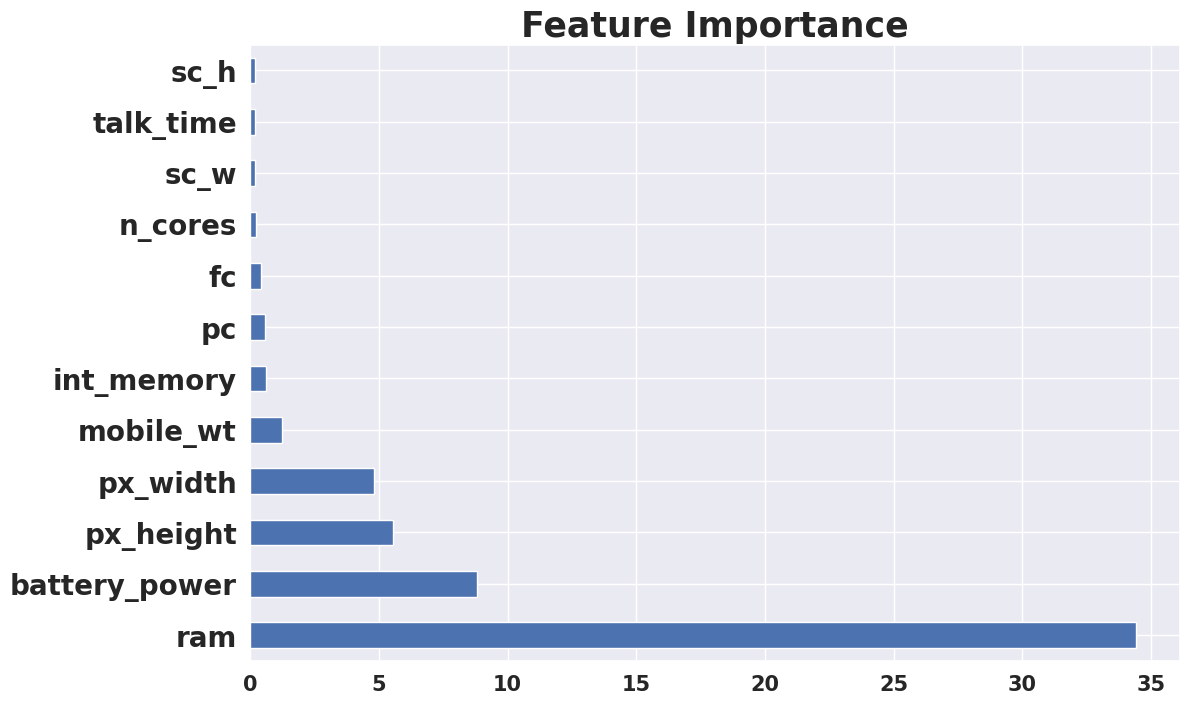

In [ ]:
plt.figure(figsize=(12,8))
pd.Series(abs(svm_optimal.coef_[0])+abs(svm_optimal.coef_[1])+abs(svm_optimal.coef_[2])+abs(svm_optimal.coef_[3]), index=X_train.columns).nlargest(12).plot(kind='barh')
plt.title('Feature Importance')
plt.show()


# **Observations**

*   Accuracy score on train set is 98.5% and Test score is 89%.

* Model seems to be overfitted as the differance between train and test accuracy score is almot 10%.
*   After Hyperparameter tuning train accuracy remained almost same 98.3% and test accuracy score increased to 97%.


*   SVM performed very well as compared to other alogorithms.

*   In terms of feature importance RAM, Battery power,px_height and px_weight are the imporatant features.
*   f1 score for individual classes is also very good. Area under curve for each class prediction is also almost 1.
















# **Final Observations From Above Predictive Modeling**

# **Observations of Decision Tree Classifier:**

**Before Hyperparameter Tuning:**


*   training accuarcy = 100%
*   test accuarcy = 84%

Model is overfitted the data and does not generalised well. So we tuned the hyperparameters.

**After Hyperparameter tuning:**


*   Training accuarcy= 98%
*  Test accuarcy = 91%

However this will not be good model for us. RAM,battery power,px_height and width came out to be the most important featrures. This model classified the class 0 and class 3 very nicely as we can see the AUC is almost 0.96 for both classes, whereas for class 1 and class 2 it is 0.88.

# **Observations of Random Forest:**

**Before Hyperparameter Tuning:**

*   training accuarcy = 100%
*   test accuarcy 88%

Model is overfitted the data and does not generalised well. So we tuned the hyperparameters.

**After Hyperparameter tuning:**

*   Training accuarcy= 100%
*   Test accuarcy 90%

We have slightly imporved the model and overfitting is reduced slightly. From roc curve its clear that model has poorly perfomed to classify class 1 and class 2

# **Observations of Gradient Boost Classifiers:**

 **Before Hyperparameter tunning:**

*   Train accuracy score=100%
*   Test accuracy score=89%

Model did not generalised well and overfitted the training data. so we tuned hyperparameters of model.

**After Hyperparameter Tuning**


*   Train accuracy score=100%
*   Test accuracy score=90%

Thus we slightly improved the model performance.However the model is not best.From ROC curve it's clear that model was good to classify the class 0 and class 3.From the classification report its clear that recall for class 0 and class 3 is also good which is 96% and 90% respectively.

# **Observations of K Nearest Neighbors:**

**Before hyperparameters tuning:**


*  Train Accuracy:75%
*   Test Accuracy:59%

Clearly Model has performed very worst. We did hyperparameter tuning

**After Hyperparameter Tuning:**


*   Train Accuracy:77%
*   Test Accuracy:70%

Surely we improved the model performance and reduced overfitting but however this is not good model for us.

# **Observations of XGBoost Classifier:**

**Before Hyperparameter Tuning:**


*   Train Accuracy=98%
*   Test Accuracy=90%

**After Hyperparameter Tuning**



*   Train Accuracy=1%
*   Test Accuracy=92%

We have improved the model performance by Hyperparameter tuning.Test accuracy is increased  to 92%. But still the difference of accuracy score between train and test is more than 5%. We can say model is very slightly overfitted From AUC-ROC curve its clear that model has almost correctly predicted the class 0 and class 3.

# **Observations of SVM:**

**Before Hyperparameter Tuning**



*   Train Accuarcy = 98.5%
*   Test Accuarcy = 89%






**After Hyperparameter Tuning**


*   Train Accuarcy = 98.3%

*   Test Accuarcy = 97%





SVM performed very well as compared to other alogorithms. In terms of feature importance RAM, Battery power,px_height and px_weight are the imporatant features. f1 score for individual classes is also very good. Area under curve for each class prediction is also almost 1.











---------------------------------------------------------------------------------------------------------------

Cross Checking whether the data is good for SVM or not by creating 4 dfs of each class.and plotting the scatterplot of most important feature "RAM" and "Battery Power".

In [ ]:
df0=mobile_data[mobile_data['price_range']==0]     # creating df of class 0
df1=mobile_data[mobile_data['price_range']==1]     # creating df of class 1
df2=mobile_data[mobile_data['price_range']==2]     # creating df of class 2
df3=mobile_data[mobile_data['price_range']==3]     # creating df of class 3


<Axes: xlabel='ram', ylabel='battery_power'>

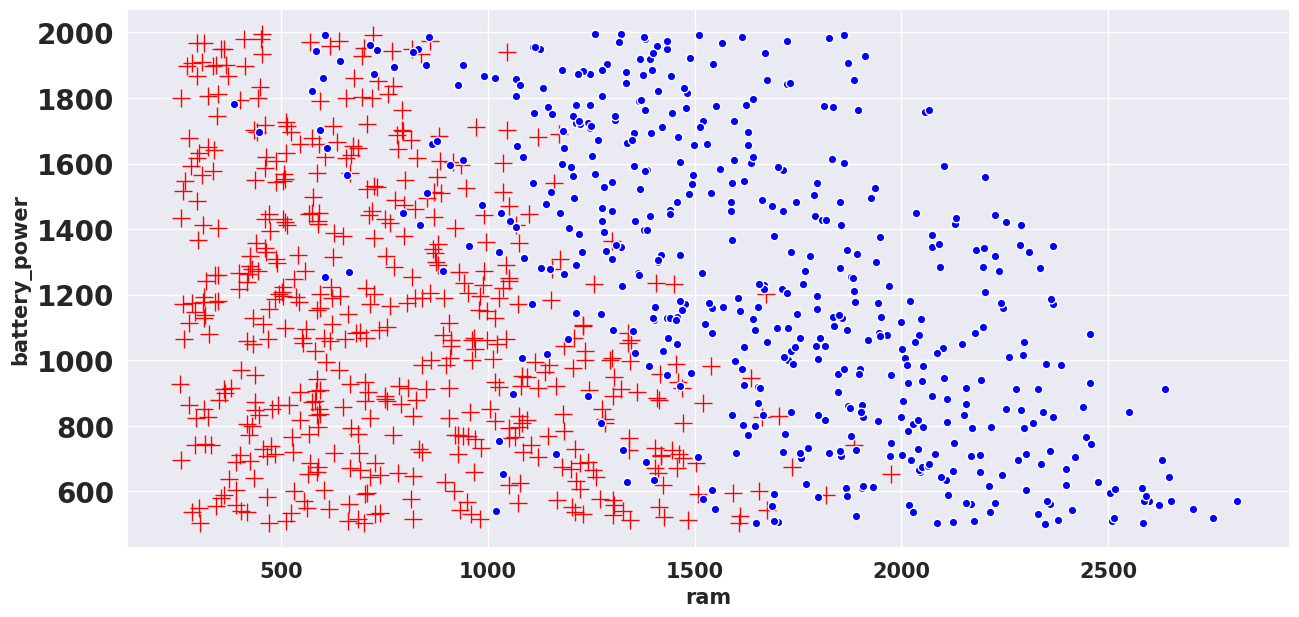

In [ ]:
plt.figure(figsize=(15,7))
sns.scatterplot(x=df0['ram'],y=df0['battery_power'],color='red',marker='+',s=150)    #scatterplot of df0-class0
sns.scatterplot(x=df1['ram'],y=df1['battery_power'],color='blue',marker='.',s=150)    #scatterplot of df1-class1

In [ ]:
svm_optimal.n_support_

array([30, 61, 58, 27], dtype=int32)

<Axes: xlabel='ram', ylabel='battery_power'>

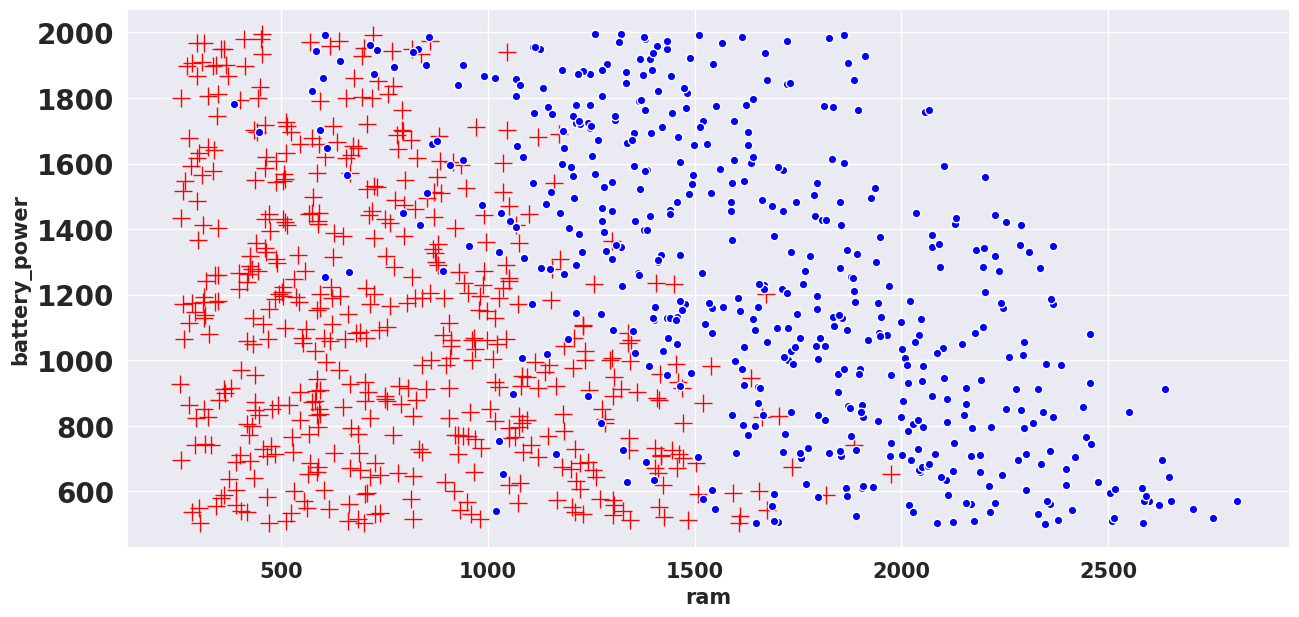

In [ ]:
plt.figure(figsize=(15,7))
sns.scatterplot(x=df0['ram'],y=df0['battery_power'],color='red',marker='+',s=150)    #scatterplot of df0-class0
sns.scatterplot(x=df1['ram'],y=df1['battery_power'],color='blue',marker='.',s=150)    #scatterplot of df1-class1

<Axes: xlabel='ram', ylabel='battery_power'>

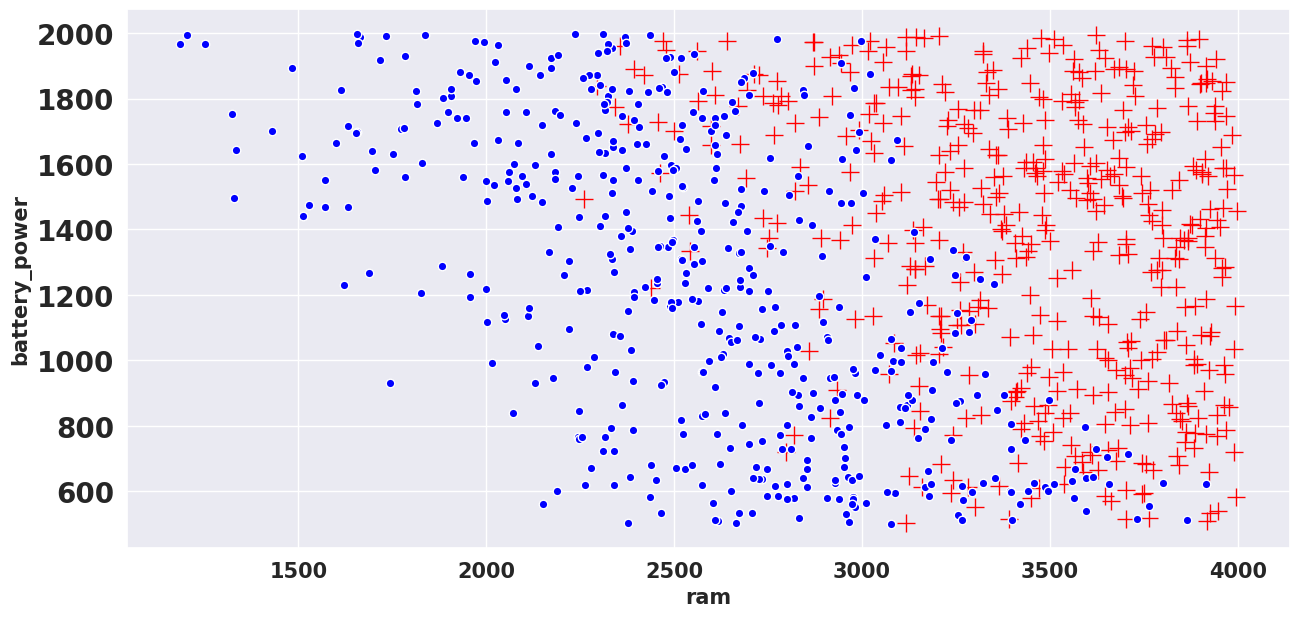

In [ ]:
plt.figure(figsize=(15,7))
sns.scatterplot(x=df3['ram'],y=df3['battery_power'],color='red',marker='+',s=150)    #scatterplot of df0-class3
sns.scatterplot(x=df2['ram'],y=df2['battery_power'],color='blue',marker='.',s=150)    #scatterplot of df1-class2

In [ ]:
# CSV file location path
file_path_1='/content/drive/MyDrive/Classification_Capstone/data_cellphone_price_precdtion.csv'

In [ ]:
# readibg Test csv file.
test_data=pd.read_csv(file_path_1)

In [ ]:
display(test_data.columns)

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [ ]:
X_test

,ram,px_height,battery_power,px_width,mobile_wt,int_memory,sc_h,talk_time,sc_w,fc,n_cores,pc
405,3419.0,250.0,1454.0,1033.0,83.0,34.0,7.0,5.0,5.0,1.0,4.0,3.0
1189,3865.0,24.0,511.0,759.0,180.0,52.0,8.0,7.0,3.0,1.0,2.0,10.0
674,969.0,182.0,1034.0,1293.0,190.0,45.0,15.0,7.0,1.0,2.0,3.0,4.0
1358,1886.0,329.0,1210.0,1039.0,111.0,57.0,16.0,17.0,9.0,9.0,4.0,20.0
810,424.0,951.0,691.0,962.0,108.0,33.0,5.0,15.0,3.0,4.0,4.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1898,770.0,786.0,1837.0,872.0,162.0,36.0,14.0,15.0,1.0,9.0,4.0,20.0
1522,324.0,773.0,1650.0,881.0,89.0,38.0,14.0,2.0,10.0,0.0,1.0,1.0
1413,2219.0,1335.0,1303.0,1873.0,109.0,10.0,9.0,15.0,3.0,6.0,8.0,15.0
1222,2454.0,274.0,1237.0,603.0,87.0,27.0,14.0,8.0,4.0,2.0,8.0,5.0


In [ ]:
test_data=test_data[X_test.columns.tolist()]

In [ ]:
test_data

,ram,px_height,battery_power,px_width,mobile_wt,int_memory,sc_h,talk_time,sc_w,fc,n_cores,pc
0,2549,20,842,756,188,7,9,19,7,1,2,2
1,2631,905,1021,1988,136,53,17,7,3,0,3,6
2,2603,1263,563,1716,145,41,11,9,2,2,5,6
3,2769,1216,615,1786,131,10,16,11,8,0,6,9
4,1411,1208,1821,1212,141,44,8,15,2,13,2,14
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,668,1222,794,1890,106,2,13,19,4,0,6,14
1996,2032,915,1965,1965,187,39,11,16,10,0,4,3
1997,3057,868,1911,1632,108,36,9,5,1,1,8,3
1998,869,336,1512,670,145,46,18,19,10,4,5,5


In [ ]:
test_data=test_data[X_test.columns.tolist()]

In [ ]:
test_data

,ram,px_height,battery_power,px_width,mobile_wt,int_memory,sc_h,talk_time,sc_w,fc,n_cores,pc
0,2549,20,842,756,188,7,9,19,7,1,2,2
1,2631,905,1021,1988,136,53,17,7,3,0,3,6
2,2603,1263,563,1716,145,41,11,9,2,2,5,6
3,2769,1216,615,1786,131,10,16,11,8,0,6,9
4,1411,1208,1821,1212,141,44,8,15,2,13,2,14
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,668,1222,794,1890,106,2,13,19,4,0,6,14
1996,2032,915,1965,1965,187,39,11,16,10,0,4,3
1997,3057,868,1911,1632,108,36,9,5,1,1,8,3
1998,869,336,1512,670,145,46,18,19,10,4,5,5


In [ ]:
svm_optimal

SVC(C=10, degree=1, gamma=0.01, kernel='linear', probability=True)

In [ ]:
X_test_data=scaler.transform(test_data)   #scaling test data as model is trained on scaled data

In [ ]:
y_pred_test_data=svm_optimal.predict(X_test_data)

In [ ]:
y_pred_test_data

array([1., 2., 2., ..., 3., 0., 3.])

In [ ]:
test_data['price_range']=y_pred_test_data

In [ ]:
test_data

,ram,px_height,battery_power,px_width,mobile_wt,int_memory,sc_h,talk_time,sc_w,fc,n_cores,pc,price_range
0,2549,20,842,756,188,7,9,19,7,1,2,2,1.0
1,2631,905,1021,1988,136,53,17,7,3,0,3,6,2.0
2,2603,1263,563,1716,145,41,11,9,2,2,5,6,2.0
3,2769,1216,615,1786,131,10,16,11,8,0,6,9,2.0
4,1411,1208,1821,1212,141,44,8,15,2,13,2,14,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,668,1222,794,1890,106,2,13,19,4,0,6,14,0.0
1996,2032,915,1965,1965,187,39,11,16,10,0,4,3,2.0
1997,3057,868,1911,1632,108,36,9,5,1,1,8,3,3.0
1998,869,336,1512,670,145,46,18,19,10,4,5,5,0.0


In [ ]:
mobile_data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842.0,0.0,2.2,0.0,1.0,0.0,7.0,0.6,188.0,2.0,2.0,20.0,756.0,2549.0,9.0,7.0,19.0,0.0,0.0,1.0,1.0
1,1021.0,1.0,0.5,1.0,0.0,1.0,53.0,0.7,136.0,3.0,6.0,905.0,1988.0,2631.0,17.0,3.0,7.0,1.0,1.0,0.0,2.0
2,563.0,1.0,0.5,1.0,2.0,1.0,41.0,0.9,145.0,5.0,6.0,1263.0,1716.0,2603.0,11.0,2.0,9.0,1.0,1.0,0.0,2.0
3,615.0,1.0,2.5,0.0,0.0,0.0,10.0,0.8,131.0,6.0,9.0,1216.0,1786.0,2769.0,16.0,8.0,11.0,1.0,0.0,0.0,2.0
4,1821.0,1.0,1.2,0.0,13.0,1.0,44.0,0.6,141.0,2.0,14.0,1208.0,1212.0,1411.0,8.0,2.0,15.0,1.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,794.0,1.0,0.5,1.0,0.0,1.0,2.0,0.8,106.0,6.0,14.0,1222.0,1890.0,668.0,13.0,4.0,19.0,1.0,1.0,0.0,0.0
1994,1965.0,1.0,2.6,1.0,0.0,0.0,39.0,0.2,187.0,4.0,3.0,915.0,1965.0,2032.0,11.0,10.0,16.0,1.0,1.0,1.0,2.0
1995,1911.0,0.0,0.9,1.0,1.0,1.0,36.0,0.7,108.0,8.0,3.0,868.0,1632.0,3057.0,9.0,1.0,5.0,1.0,1.0,0.0,3.0
1996,1512.0,0.0,0.9,0.0,4.0,1.0,46.0,0.1,145.0,5.0,5.0,336.0,670.0,869.0,18.0,10.0,19.0,1.0,1.0,1.0,0.0


In [ ]:
mobile_data[mobile_data['ram']==3283]

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
21,1709.0,1.0,2.1,0.0,1.0,0.0,13.0,1.0,156.0,2.0,2.0,974.0,1385.0,3283.0,17.0,1.0,15.0,1.0,0.0,0.0,3.0


In [ ]:
test_data[test_data['ram']==3283]

,ram,px_height,battery_power,px_width,mobile_wt,int_memory,sc_h,talk_time,sc_w,fc,n_cores,pc,price_range
21,3283,974,1709,1385,156,13,17,15,1,1,2,2,3.0


# **Challenges Faced**:

During the development of the Cellphone Price Range Prediction project, several challenges were encountered at both technical and analytical levels. These challenges are grouped into minor and major categories.

**Minor Challenges**:

**1.   Environment Setup and Dependencies:**
At the beginning, setting up Jupyter Notebook and installing the required Python libraries (such as pandas, scikit-learn, matplotlib, numpy) was a hurdle. Some version mismatches caused errors, which required troubleshooting and reinstalling compatible packages.

**2.  Understanding the Dataset:**
Certain column names, such as fc, pc, and m_dep, were not intuitive at first glance. Additional effort was needed to understand or infer their meaning from the dataset documentation before moving forward with the analysis.


**Major Challenges:**


**1.  Data Availability and Quality:**
The actual dataset was not always easily accessible, and in some cases, synthetic data had to be generated to simulate real conditions. This introduced limitations since synthetic data cannot perfectly reflect market behavior or real-world patterns. Handling missing values and ensuring the reliability of the dataset was also a challenge.

**2.  Model Selection and Hyperparameter Tuning:**
Choosing the most suitable algorithm for classification was not straightforward. Several models like RandomForest, Decision Trees, and SVM were considered, each with strengths and weaknesses. Hyperparameter tuning through grid search was computationally expensive and time-consuming, especially as the dataset grew larger. Achieving a balance between accuracy, generalization, and computational efficiency required significant effort.




# **Conclusion:**

*   We Started with Data understanding, data wrangling, basic EDA where we found the relationship trends between price range and other independent variables.

*   We selected the best features for predictive modeling by using K best feature selection method using Chi square statistic.


*   Implemented various classification algorithms, out of which the SM(Support vector machine) algorithm gave the best performance after hyper-parameter tuning with 98.3% train accuracy and 97% test accuracy.
*  XG boost is the second best good model which gave good performance after hyper-parameter tuning with 100% train accuracy and 92.25% test accuracy score.


*  KNN gave very worst model performance.


*   We checked for the feature importance's of each model. RAM, Battery Power, Px_height and px_width contributed the most while predicting the price range.












